# 수출 속보치 결합·예측 파이프라인

용도별로 셀을 나눠서, 필요한 부분만 골라 실행하거나 전체를 순서대로 실행할 수 있도록 구성했습니다.

**노트북 구성**
1. 환경 설정 (패키지 설치, 공통 임포트, 한글 폰트)
2. DB 레이어 (SQLite/MySQL 겸용)
3. 잠정치 엑셀 파서
4. 속보치 → 월간 표준화 & 히스토리 결합
5. 예측 함수 모듈 (SARIMA / ETS / Theta / Prophet / LSTM) — 사용자 제공 원본
6. 예측 앙상블 래퍼 (SARIMA+Theta+ETS 평균)
7. 시각화 & 리포트 생성
8. 파이프라인 오케스트레이터 (1개 HS코드 처리 함수)
9. 실행 — 테스트 (SQLite, 이 노트북에서 바로 검증 가능)
10. 실행 — 운영 (MySQL, 실제 DB 접속 환경에서만 실행)

> ⚠️ 셀은 **위에서부터 순서대로 한 번씩** 실행해야 합니다 (뒤 섹션이 앞 섹션에서 정의한 함수를 사용합니다).
> 9번(SQLite 테스트)과 10번(MySQL 운영) 중 필요한 것만 실행하면 됩니다.


## 1. 환경 설정

In [1]:
# 최초 1회만 실행 (이미 설치되어 있으면 건너뛰어도 됩니다)
# %pip install pandas numpy openpyxl sqlalchemy pymysql statsmodels matplotlib

In [2]:
%matplotlib inline

In [3]:
# ── 공통 임포트 ──────────────────────────────────────────────
import os
import re
import sys
import calendar
import warnings
from dataclasses import dataclass
from datetime import date, datetime
from pathlib import Path

import numpy as np
import pandas as pd
from openpyxl import load_workbook
from sqlalchemy import create_engine, text, inspect as sa_inspect

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display, Markdown, Image

warnings.filterwarnings("ignore")


def _setup_korean_font():
    candidates = ["NanumGothic", "Malgun Gothic", "AppleGothic", "Noto Sans CJK KR", "Noto Sans KR"]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False


_setup_korean_font()
print("환경 설정 완료")

환경 설정 완료


## 2. DB 레이어

`backend="sqlite"`(테스트) / `backend="mysql"`(운영) 겸용.

MySQL 접속정보는 코드에 하드코딩하지 않고 환경변수에서 읽습니다:
`KOREA_TRADE_DB_HOST`, `KOREA_TRADE_DB_PORT`(기본 3307), `KOREA_TRADE_DB_USER`,
`KOREA_TRADE_DB_PASSWORD`, `KOREA_TRADE_DB_NAME`


**속보치 원본 테이블(`korea_export_quick_report_data`)은 append-only입니다.**
같은 기간(report_date)을 여러 번 수집해도(정정 발표·재수집 등) 덮어쓰지 않고 `collected_at`
시각과 함께 매번 새 행으로 쌓입니다. 전체 이력은 `get_flash_history()`, 가장 최근 수집본만
필요하면 `get_latest_flash_snapshot()`을 사용하세요.

In [4]:
import os
from datetime import datetime

import pandas as pd
from sqlalchemy import create_engine, text


# -----------------------------------------------------------------------------
# 엔진 생성
# -----------------------------------------------------------------------------
def get_engine(backend: str = "sqlite", sqlite_path: str = "export_pipeline.db"):
    if backend == "sqlite":
        return create_engine(f"sqlite:///{sqlite_path}")

    if backend == "mysql":
        host = os.environ.get("KOREA_TRADE_DB_HOST")
        port = os.environ.get("KOREA_TRADE_DB_PORT", "3307")
        user = os.environ.get("KOREA_TRADE_DB_USER")
        password = os.environ.get("KOREA_TRADE_DB_PASSWORD")
        database = os.environ.get("KOREA_TRADE_DB_NAME", "investar")

        # host를 환경변수로 안 넣었다면, 기존 노트북과 동일하게
        # DATA.stock_invest_function.get_db_host()로 자동 조회를 시도한다 (best-effort).
        if not host:
            try:
                setup_universal_paths(verbose=False)
                from DATA.stock_invest_function import get_db_host
                host = get_db_host()
            except Exception:
                pass

        missing = [k for k, v in {
            "KOREA_TRADE_DB_HOST": host,
            "KOREA_TRADE_DB_USER": user,
            "KOREA_TRADE_DB_PASSWORD": password,
        }.items() if not v]
        if missing:
            raise EnvironmentError(
                f"MySQL 접속에 필요한 환경변수가 없습니다: {missing}\n"
                f"사용자 PC에서 실행 전 환경변수를 설정하세요 "
                f"(예: export KOREA_TRADE_DB_HOST=... ), "
                f"또는 DATA.stock_invest_function.get_db_host()가 정상 동작하는지 확인하세요."
            )

        url = f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}"
        return create_engine(url, pool_size=10, max_overflow=10)

    raise ValueError(f"지원하지 않는 backend: {backend}")


# -----------------------------------------------------------------------------
# 잠정치(속보치) 원본 테이블  ── append-only (절대 덮어쓰지 않음)
#   - 같은 기간(report_date)을 여러 번 수집해도(정정 발표, 재수집 등) 모두 별도 행으로 쌓인다.
#   - collected_at(수집 시각)으로 각 수집 시점을 구분하고,
#     자동증가 id를 PK로 써서 (report_date, hs_code, country) 조합이 같아도 항상 새로 추가(INSERT)된다.
# -----------------------------------------------------------------------------
FLASH_TABLE = "korea_export_quick_report_data"

FLASH_TABLE_DDL_SQLITE = f"""
CREATE TABLE IF NOT EXISTS {FLASH_TABLE} (
    id            INTEGER PRIMARY KEY AUTOINCREMENT,
    collected_at  TEXT,
    report_date   TEXT,
    hs_code       TEXT,
    item_name     TEXT,
    country       TEXT,
    amount_usd    REAL,
    amount_krw    REAL,
    weight_kg     REAL,
    period_label  TEXT
);
"""

FLASH_TABLE_DDL_MYSQL = f"""
CREATE TABLE IF NOT EXISTS {FLASH_TABLE} (
    id            BIGINT AUTO_INCREMENT PRIMARY KEY,
    collected_at  DATETIME,
    report_date   DATE,
    hs_code       VARCHAR(20),
    item_name     VARCHAR(200),
    country       VARCHAR(100),
    amount_usd    DOUBLE,
    amount_krw    DOUBLE,
    weight_kg     DOUBLE,
    period_label  VARCHAR(50),
    INDEX idx_flash_lookup (hs_code, report_date, country)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
"""

FLASH_TABLE_INDEX_SQLITE = f"""
CREATE INDEX IF NOT EXISTS idx_flash_lookup
ON {FLASH_TABLE} (hs_code, report_date, country);
"""


def _migrate_old_flash_table_if_needed(engine, backend: str):
    """
    예전 버전 코드로 이미 만들어져 있던 korea_export_quick_report_data 테이블
    (PK: report_date+hs_code+country, collected_at 컬럼 없음)을 감지해서
    새 append-only 스키마로 자동 마이그레이션한다.

    - 기존 테이블 -> {FLASH_TABLE}_old_backup 으로 이름 변경(데이터 보존, 삭제하지 않음)
    - 새 스키마로 {FLASH_TABLE} 재생성
    - 백업 테이블의 기존 데이터를 collected_at=마이그레이션 시각으로 채워서 새 테이블로 이관
    이미 새 스키마(collected_at 컬럼 존재)면 아무것도 하지 않고 조용히 넘어간다.
    """
    from sqlalchemy import inspect as sa_inspect

    insp = sa_inspect(engine)
    if not insp.has_table(FLASH_TABLE):
        return  # 테이블 자체가 없으면 마이그레이션할 것도 없음 (새로 생성될 것)

    existing_cols = [c["name"] for c in insp.get_columns(FLASH_TABLE)]
    if "collected_at" in existing_cols:
        return  # 이미 새 스키마

    backup_name = f"{FLASH_TABLE}_old_backup"
    print(f"[마이그레이션] 구버전 {FLASH_TABLE} 테이블을 발견했습니다 "
          f"(collected_at 컬럼 없음). 새 append-only 스키마로 이관합니다.")

    with engine.begin() as conn:
        # 혹시 이전에 마이그레이션하다 중단된 이력이 있으면 이름 충돌 방지
        if sa_inspect(engine).has_table(backup_name):
            backup_name = f"{backup_name}_{datetime.now().strftime('%Y%m%d%H%M%S')}"
        conn.execute(text(f"ALTER TABLE {FLASH_TABLE} RENAME TO {backup_name}"))

    # 새 스키마로 재생성
    ddl = FLASH_TABLE_DDL_SQLITE if backend == "sqlite" else FLASH_TABLE_DDL_MYSQL
    with engine.connect() as conn:
        conn.execute(text(ddl))
        if backend == "sqlite":
            conn.execute(text(FLASH_TABLE_INDEX_SQLITE))
        conn.commit()

    # 기존 데이터를 새 스키마로 이관 (collected_at은 마이그레이션 시각으로 일괄 채움 —
    # 원래 수집 시각 정보가 없었으므로 "최소한 이 시점 이전에 수집된 데이터"라는 의미로 남김)
    old_data = pd.read_sql(text(f"SELECT * FROM {backup_name}"), engine)
    if not old_data.empty:
        old_data["collected_at"] = datetime.now().isoformat(timespec="seconds")
        keep_cols = ["collected_at", "report_date", "hs_code", "item_name",
                     "country", "amount_usd", "amount_krw", "weight_kg", "period_label"]
        old_data = old_data[[c for c in keep_cols if c in old_data.columns]]
        with engine.begin() as conn:
            old_data.to_sql(FLASH_TABLE, conn, if_exists="append", index=False)

    print(f"[마이그레이션 완료] 기존 데이터 {len(old_data)}건을 새 스키마로 이관했습니다. "
          f"원본은 '{backup_name}' 테이블에 그대로 백업되어 있습니다(삭제 안 함).")


def init_flash_table(engine, backend: str):
    _migrate_old_flash_table_if_needed(engine, backend)

    ddl = FLASH_TABLE_DDL_SQLITE if backend == "sqlite" else FLASH_TABLE_DDL_MYSQL
    with engine.connect() as conn:
        conn.execute(text(ddl))
        if backend == "sqlite":
            conn.execute(text(FLASH_TABLE_INDEX_SQLITE))
        conn.commit()


def insert_flash_data(engine, backend: str, df: pd.DataFrame, hs_code: str,
                       report_date, period_label: str):
    """
    잠정치 엑셀에서 파싱한 국가별 데이터를 그대로 DB에 '추가'(append-only)로 저장.
    같은 (report_date, hs_code, country) 조합을 다시 수집해도 절대 덮어쓰지 않고
    collected_at(현재 시각)을 찍어 새 행으로 쌓는다 (정정 발표·재수집 이력 보존 목적).
    """
    init_flash_table(engine, backend)

    now = datetime.now().isoformat(timespec="seconds")

    out = df.copy()
    out["collected_at"] = now
    out["report_date"] = str(report_date)
    out["hs_code"] = hs_code
    out["period_label"] = period_label
    out = out[["collected_at", "report_date", "hs_code", "item_name", "country",
               "amount_usd", "amount_krw", "weight_kg", "period_label"]]

    with engine.begin() as conn:
        out.to_sql(FLASH_TABLE, conn, if_exists="append", index=False)

    return len(out)


# 하위 호환용 별칭 (기존 노트북 셀에서 upsert_flash_data(...)로 호출하던 코드가 있어도 그대로 동작)
def upsert_flash_data(engine, backend: str, df: pd.DataFrame, hs_code: str,
                       report_date, period_label: str):
    return insert_flash_data(engine, backend, df, hs_code, report_date, period_label)


def get_flash_history(engine, hs_code: str, report_date=None) -> pd.DataFrame:
    """
    해당 HS코드(+선택적으로 특정 report_date)의 '모든 수집 이력'을 collected_at 포함해서 전부 반환.
    같은 기간을 여러 번 수집했다면 그 모든 버전이 다 나온다 (감사/추적용).
    """
    q = f"SELECT * FROM {FLASH_TABLE} WHERE hs_code = :hs_code"
    params = {"hs_code": hs_code}
    if report_date is not None:
        q += " AND report_date = :report_date"
        params["report_date"] = str(report_date)
    q += " ORDER BY report_date, country, collected_at"
    with engine.connect() as conn:
        return pd.read_sql(text(q), conn, params=params)


def get_latest_flash_snapshot(engine, hs_code: str, report_date=None) -> pd.DataFrame:
    """
    (report_date, country)별로 '가장 최근에 수집된(collected_at 최대)' 버전만 반환.
    같은 기간을 여러 번 수집했어도, 분석 파이프라인은 보통 최신 버전 하나만 쓰면 되므로
    process_one_file() 등에서는 이 함수 결과를 쓰는 걸 권장.
    """
    hist = get_flash_history(engine, hs_code, report_date)
    if hist.empty:
        return hist
    hist["collected_at"] = pd.to_datetime(hist["collected_at"])
    idx = hist.groupby(["report_date", "country"])["collected_at"].idxmax()
    return hist.loc[idx].sort_values(["report_date", "country"]).reset_index(drop=True)


def read_flash_data(engine, hs_code: str, report_date=None) -> pd.DataFrame:
    """참고: 이 함수는 append-only 테이블의 원본 그대로(중복 수집 포함)를 반환한다.
    최신 수집본만 필요하면 get_latest_flash_snapshot()을 사용할 것."""
    q = f"SELECT * FROM {FLASH_TABLE} WHERE hs_code = :hs_code"
    params = {"hs_code": hs_code}
    if report_date is not None:
        q += " AND report_date = :report_date"
        params["report_date"] = str(report_date)
    with engine.connect() as conn:
        return pd.read_sql(text(q), conn, params=params)


# -----------------------------------------------------------------------------
# 기존 월별 히스토리 (노트북이 적재하는 korea_monthly_trade_data, long format)
# -----------------------------------------------------------------------------
MONTHLY_HISTORY_TABLE = "korea_monthly_trade_data"


def read_monthly_history(engine, hs_code: str) -> pd.DataFrame:
    """
    korea_monthly_trade_data(date, root_hs_code, indicator, value)에서
    해당 HS코드의 expDlr(수출금액), expWgt(수출중량)만 읽어온다.
    """
    from sqlalchemy import inspect as sa_inspect

    if not sa_inspect(engine).has_table(MONTHLY_HISTORY_TABLE):
        return pd.DataFrame(columns=["date", "hs_code", "indicator", "value"])

    q = f"""
        SELECT date, root_hs_code AS hs_code, indicator, value
        FROM {MONTHLY_HISTORY_TABLE}
        WHERE root_hs_code = :hs_code
          AND indicator IN ('expDlr', 'expWgt')
    """
    with engine.connect() as conn:
        df = pd.read_sql(text(q), conn, params={"hs_code": hs_code})
    if df.empty:
        return df
    df["date"] = pd.to_datetime(df["date"])
    return df


def monthly_history_wide(engine, hs_code: str) -> pd.DataFrame:
    """
    long -> wide 변환: index=date(월말), columns=[expDlr, expWgt]
    """
    long_df = read_monthly_history(engine, hs_code)
    if long_df.empty:
        return pd.DataFrame(columns=["expDlr", "expWgt"])

    wide = long_df.pivot_table(index="date", columns="indicator", values="value", aggfunc="sum")
    wide = wide.sort_index()
    return wide


# -----------------------------------------------------------------------------
# 테스트/데모용: SQLite에 가상 히스토리 데이터 채워넣기
# (실제 MySQL DB에 접근할 수 없는 샌드박스 환경에서 파이프라인을 검증하기 위한 용도)
# -----------------------------------------------------------------------------
def seed_fake_monthly_history(engine, hs_code: str, n_months: int = 72,
                               base_amount: float = 2_000_000_000,
                               base_weight: float = 20_000, seed: int = 0):
    import numpy as np
    rng = np.random.default_rng(seed + sum(ord(c) for c in hs_code))

    end = pd.Timestamp("2026-06-30")
    dates = pd.date_range(end=end, periods=n_months, freq="ME")

    rows = []
    for i, d in enumerate(dates):
        trend = 1 + 0.003 * i
        seasonal = 1 + 0.08 * np.sin(2 * np.pi * d.month / 12)
        noise_amt = rng.normal(1, 0.06)
        noise_wgt = rng.normal(1, 0.05)
        amt = base_amount * trend * seasonal * noise_amt
        wgt = base_weight * trend * seasonal * noise_wgt
        rows.append({"date": d.date().isoformat(), "root_hs_code": hs_code, "indicator": "expDlr", "value": amt})
        rows.append({"date": d.date().isoformat(), "root_hs_code": hs_code, "indicator": "expWgt", "value": wgt})

    df = pd.DataFrame(rows)

    ddl = f"""
    CREATE TABLE IF NOT EXISTS {MONTHLY_HISTORY_TABLE} (
        date TEXT, root_hs_code TEXT, indicator TEXT, value REAL,
        PRIMARY KEY (date, root_hs_code, indicator)
    );
    """
    with engine.begin() as conn:
        conn.execute(text(ddl))
        for _, row in df.iterrows():
            conn.execute(text(f"""
                INSERT INTO {MONTHLY_HISTORY_TABLE} (date, root_hs_code, indicator, value)
                VALUES (:date, :root_hs_code, :indicator, :value)
                ON CONFLICT(date, root_hs_code, indicator) DO UPDATE SET value=excluded.value
            """), row.to_dict())

    return df

## 3. 잠정치 엑셀 파서

2행의 조회조건 문자열에서 HS코드·조회기간을 추출하고, 4행부터 국가별 데이터를 읽습니다.

**주의**: `openpyxl`을 `read_only=True`로 열면 일부 엑셀에서 dimension 메타데이터가 깨져
전체 행을 못 읽는 문제가 있어 `read_only=False`를 사용합니다.


In [5]:
import re

import calendar
from dataclasses import dataclass
from datetime import date

import pandas as pd
from datetime import timedelta
from openpyxl import load_workbook


def _busday_count_inclusive(start_d, end_d) -> int:
    """start_d~end_d(둘 다 포함)의 영업일(월~금) 수를 셈. 공휴일은 미반영(주말만 제외)."""
    import numpy as np
    return int(np.busday_count(start_d, end_d + timedelta(days=1)))


@dataclass
class FlashPeriod:
    year: int
    month: int
    day_start: int
    day_end: int

    @property
    def report_date(self) -> date:
        """엑셀에 기록된 기간의 마지막 날짜를 '저장 기준일'로 사용 (예: 07월01~20일 -> 2026-07-20)"""
        return date(self.year, self.month, self.day_end)

    @property
    def days_in_period(self) -> int:
        return self.day_end - self.day_start + 1

    @property
    def days_in_month(self) -> int:
        return calendar.monthrange(self.year, self.month)[1]

    @property
    def is_full_month(self) -> bool:
        return self.day_start == 1 and self.day_end == self.days_in_month

    @property
    def business_days_in_period(self) -> int:
        """조회기간(day_start~day_end) 내 영업일(월~금) 수."""
        start = date(self.year, self.month, self.day_start)
        end = date(self.year, self.month, self.day_end)
        return _busday_count_inclusive(start, end)

    @property
    def business_days_in_month(self) -> int:
        """해당 월 전체의 영업일(월~금) 수."""
        start = date(self.year, self.month, 1)
        end = date(self.year, self.month, self.days_in_month)
        return _busday_count_inclusive(start, end)

    @property
    def period_label(self) -> str:
        return f"{self.year}년{self.month:02d}월{self.day_start:02d}~{self.day_end:02d}일"


CONDITION_RE = re.compile(
    r"HSCODE\s*:\s*\(?'?(?P<hs>\d+)'?\)?.*?"
    r"기간\s*:\s*(?P<year>\d{4})년(?P<month>\d{2})월(?P<d1>\d{2})~(?P<d2>\d{2})일",
    re.DOTALL,
)


def parse_condition_line(line: str):
    """조회조건 문자열에서 HS코드와 기간을 추출"""
    m = CONDITION_RE.search(line)
    if not m:
        raise ValueError(f"조회조건 문자열을 파싱할 수 없습니다: {line!r}")

    hs_code = m.group("hs")
    period = FlashPeriod(
        year=int(m.group("year")),
        month=int(m.group("month")),
        day_start=int(m.group("d1")),
        day_end=int(m.group("d2")),
    )
    return hs_code, period


def parse_flash_excel(path: str) -> dict:
    """
    잠정치 조회 엑셀 1개 파일을 파싱.

    Returns
    -------
    {
        "hs_code": str,
        "period": FlashPeriod,
        "df": pd.DataFrame[품목코드, 품목명, 국가명, 금액(달러), 금액(원화), 중량(Kg)]
    }
    """
    wb = load_workbook(path, read_only=False, data_only=True)
    ws = wb["DATA"] if "DATA" in wb.sheetnames else wb.active

    rows = list(ws.iter_rows(values_only=True))
    if len(rows) < 4:
        raise ValueError(f"예상보다 행이 적습니다: {path}")

    condition_line = rows[1][0]
    hs_code, period = parse_condition_line(str(condition_line))

    header_row_idx = None
    for i, row in enumerate(rows):
        if row and row[0] == "순번":
            header_row_idx = i
            break
    if header_row_idx is None:
        raise ValueError(f"헤더 행('순번')을 찾을 수 없습니다: {path}")

    header = list(rows[header_row_idx])
    data_rows = [r for r in rows[header_row_idx + 1:] if r and r[0] is not None]

    df = pd.DataFrame(data_rows, columns=header)
    df = df.rename(columns={
        "품목코드": "hs_code",
        "품목명": "item_name",
        "국가명": "country",
        "금액(달러)": "amount_usd",
        "금액(원화)": "amount_krw",
        "중량(Kg)": "weight_kg",
    })
    df = df.drop(columns=["순번"], errors="ignore")
    df["hs_code"] = df["hs_code"].astype(str)

    for col in ["amount_usd", "amount_krw", "weight_kg"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

    return {"hs_code": hs_code, "period": period, "df": df}

## 4. 속보치 → 월간 표준화 & 히스토리 결합

- 국가별 데이터를 먼저 전체 합산(총계)
- **수출금액 월간 환산**: 기본적으로 **영업일(월~금) 수 비례**로 계산 (`method="business_day"`).
  주말에는 통관이 거의 없다는 점을 반영해, 단순 달력일 비례보다 더 합리적인 기본 추정치.
  달력일 기준 값도 참고용으로 함께 계산해서 남겨둠(`calendar_day_scale`, `business_day_scale` 비교 가능).
  ⚠️ 공휴일은 반영하지 못하는 한계가 있음(주말만 제외). 과거 데이터가 쌓이면 계절 패턴(r-value) 기반 보정으로 교체 권장.
- 수출단가($/kg): 금액/중량 비율이라 배율 적용 없이 그대로 계산
- 기존 월별 히스토리(`korea_monthly_trade_data`)에 당월을 속보치로 덮어써서 결합
- 원본(부분기간) 실적은 `raw_partial_amount_usd`로 별도 보존, 각 행의 `status`(`confirmed`/`flash_estimate`)로
  확정치인지 속보 추정치인지 명확히 구분


In [6]:
import pandas as pd


def aggregate_countries(flash_df: pd.DataFrame) -> dict:
    """국가별 잠정치 데이터를 전체 합산(총계)으로 집계"""
    total_amount_usd = flash_df["amount_usd"].sum()
    total_weight_kg = flash_df["weight_kg"].sum()
    return {"amount_usd": total_amount_usd, "weight_kg": total_weight_kg}


def standardize_to_monthly(flash_totals: dict, period, method: str = "business_day") -> dict:
    """
    부분기간(10일/20일 등) 합산치를 월간 단위로 표준화.

    method:
      - "business_day" (기본값, 권장): 영업일(월~금) 수 비례.
            주말에는 통관이 거의 없다는 점을 반영해 달력일 비례보다 더 합리적인 기본 추정치.
            공휴일은 반영하지 못하는 한계가 있음(달력상 주말만 제외).
      - "calendar_day": 해당월 일수/조회기간 일수 비례 (예전 방식, 참고/비교용으로 계속 계산해 둠).

    이미 월 전체(is_full_month=True)라면 두 방식 모두 배율 1.0.

    과거 실측 기반 계절 패턴 비율(r-value)이 없는 상태에서 적용 가능한 방법 중
    가장 합리적인 기본값이 "영업일 비례"라고 판단해 기본 method로 채택함.
    추후 과거 데이터가 쌓이면 계절 패턴 보정(방법 C)으로 교체 권장.
    """
    if period.is_full_month:
        cal_scale = 1.0
        biz_scale = 1.0
    else:
        cal_scale = period.days_in_month / period.days_in_period
        # 영업일이 0일인 예외적 경우(조회기간이 전부 주말/공휴일) 대비 가드
        biz_scale = (
            period.business_days_in_month / period.business_days_in_period
            if period.business_days_in_period else cal_scale
        )

    scale = biz_scale if method == "business_day" else cal_scale

    raw_amount_usd = flash_totals["amount_usd"]
    raw_weight_kg = flash_totals["weight_kg"]

    amount_usd_monthly_est = raw_amount_usd * scale
    weight_kg_monthly_est = raw_weight_kg * scale

    # 수출단가($/kg)는 금액/중량 비율이라 배율과 무관 (배율을 곱해도 분자·분모에 똑같이 곱해져 상쇄됨)
    unit_price = (
        raw_amount_usd / raw_weight_kg if raw_weight_kg else float("nan")
    )

    return {
        # 최종 채택 추정치 (method 파라미터에 따름)
        "amount_usd_monthly_est": amount_usd_monthly_est,
        "weight_kg_monthly_est": weight_kg_monthly_est,
        "unit_price_usd_per_kg": unit_price,
        "scale_factor": scale,
        "method_used": method,
        "is_full_month": period.is_full_month,

        # 원본 보존 (raw) — 검증/투명성 목적으로 항상 같이 남겨둠
        "raw_amount_usd": raw_amount_usd,
        "raw_weight_kg": raw_weight_kg,

        # 참고용 비교 지표 (두 방식이 얼마나 차이 나는지 바로 확인 가능하도록)
        "calendar_day_scale": cal_scale,
        "business_day_scale": biz_scale,
        "amount_usd_monthly_est_calendar": raw_amount_usd * cal_scale,
        "amount_usd_monthly_est_business": raw_amount_usd * biz_scale,
    }


def build_combined_monthly_series(history_wide: pd.DataFrame, flash_std: dict,
                                   period) -> pd.DataFrame:
    """
    기존 월별 히스토리(wide: expDlr, expWgt)에 속보치로 표준화한 당월 추정치를 결합.
    - 히스토리에 당월(같은 연-월) 데이터가 이미 있으면 속보치로 덮어쓴다(더 최신 신호이므로).
    - 없으면 새 행으로 추가한다.
    - status 컬럼으로 각 행이 "확정치(confirmed)"인지 "당월 속보 추정치(flash_estimate)"인지 명시.
    - 당월 행에는 raw_partial_amount_usd(원본 부분기간 실적)도 같이 남겨서,
      나중에 검증하거나 다른 보정 방법으로 다시 계산할 때 원본이 사라지지 않도록 함.
    반환: date, 수출금액, 수출중량, 수출단가, status, raw_partial_amount_usd, scale_factor, method_used
    """
    out = history_wide.copy()
    out = out.rename(columns={"expDlr": "수출금액", "expWgt": "수출중량"})

    current_month_end = pd.Timestamp(
        year=period.year, month=period.month, day=period.days_in_month
    )

    out["status"] = "confirmed"
    out["raw_partial_amount_usd"] = pd.NA
    out["scale_factor"] = 1.0
    out["method_used"] = "actual"

    out.loc[current_month_end, "수출금액"] = flash_std["amount_usd_monthly_est"]
    out.loc[current_month_end, "수출중량"] = flash_std["weight_kg_monthly_est"]
    out.loc[current_month_end, "status"] = (
        "confirmed" if flash_std["is_full_month"] else "flash_estimate"
    )
    out.loc[current_month_end, "raw_partial_amount_usd"] = flash_std["raw_amount_usd"]
    out.loc[current_month_end, "scale_factor"] = flash_std["scale_factor"]
    out.loc[current_month_end, "method_used"] = flash_std["method_used"]

    out = out.sort_index()
    out["수출단가"] = out["수출금액"] / out["수출중량"]
    out.index.name = "date"

    # 하위 호환: 기존에 is_flash 컬럼을 참조하는 곳이 있을 수 있어 같이 남겨둠
    out["is_flash"] = out["status"] != "confirmed"

    return out.reset_index()


## 5. 범용 경로 설정 + 예측 함수 모듈 임포트

`universal_ts_forecast_function_v2.py`는 데스크탑/노트북에서 위치가 다른 **DATA 폴더**
(예: `C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA`)에 있습니다.

`한국수출입데이터_수집_V5.ipynb`에서 쓰던 것과 동일한 범용 경로 탐색 로직을 재사용해서,
어떤 PC에서 실행하든 자동으로 DATA 폴더를 찾아 `sys.path`에 추가한 뒤 모듈을 임포트합니다.

- 1순위: 현재 노트북 위치 기준 상위 폴더에서 `DATA` 폴더 자동 탐색
- 2순위: 아래 `KNOWN_DATA_PATHS`(두 PC의 고정 경로) 중 존재하는 경로 사용
- 새 PC를 추가하려면 `KNOWN_DATA_PATHS` 리스트에 경로만 추가하면 됩니다.

**중요 제약**: 예측 함수는 월간 데이터 최소 60개월 연속 무결측 구간이 없으면
`coerce_pivot_to_target_series_strict()`에서 예외를 발생시키고,
`forecast_one_from_pivot_inline()`은 이를 잡아 `{"error": ...}`를 반환합니다.


In [7]:
# 두 PC의 알려진 DATA 폴더 경로 (fallback용) — 새 PC 추가 시 이 목록에 경로만 추가하면 됩니다.
KNOWN_DATA_PATHS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast\DATA",          # 데스크탑
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA",  # 노트북
]


def setup_universal_paths(known_data_paths=None, folder_name: str = "DATA",
                           start_path=None, verbose: bool = True) -> str:
    """어떤 PC에서도 작동하는 범용 경로 설정: DATA 폴더 자동 탐색 + 고정 경로 fallback"""
    known_data_paths = known_data_paths if known_data_paths is not None else KNOWN_DATA_PATHS

    # 1) 현재 위치 기준 상위 폴더로 올라가며 DATA 폴더 자동 탐색
    current = Path(start_path) if start_path else Path.cwd()
    for parent in [current, *current.parents]:
        data_folder = parent / folder_name
        if data_folder.exists():
            for p in (str(parent), str(data_folder)):
                if p not in sys.path:
                    sys.path.insert(0, p)
            if verbose:
                print(f"[경로 설정] 자동 탐색 성공 | 프로젝트 루트: {parent}")
                print(f"[경로 설정] {folder_name} 폴더: {data_folder}")
            return str(data_folder)

    # 2) 고정 경로 fallback (자동 탐색 실패 시)
    for dp in known_data_paths:
        if os.path.exists(dp):
            root = str(Path(dp).parent)
            for p in (root, dp):
                if p not in sys.path:
                    sys.path.insert(0, p)
            if verbose:
                print(f"[경로 설정] 고정 경로 사용 | 프로젝트 루트: {root}")
                print(f"[경로 설정] {folder_name} 폴더: {dp}")
            return dp

    raise FileNotFoundError(
        f"{folder_name} 폴더를 찾을 수 없습니다.\n"
        f"현재 위치: {current}\n"
        f"상위 폴더에 {folder_name} 폴더가 있는지, 또는 KNOWN_DATA_PATHS의 경로가 맞는지 확인하세요."
    )


DATA_PATH = setup_universal_paths()
import universal_ts_forecast_function_v2 as uf

print("예측 함수 모듈 임포트 완료 | DATA_PATH:", DATA_PATH)
print(f"사용 가능한 모델: SARIMA, ETS, Theta={'OK' if uf._HAS_THETA else '미설치'}, "
      f"Prophet={'OK' if uf._HAS_PROPHET else '미설치'}, LSTM={'OK' if uf._HAS_TF else '미설치'}")

[경로 설정] 자동 탐색 성공 | 프로젝트 루트: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[경로 설정] DATA 폴더: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA
예측 함수 모듈 임포트 완료 | DATA_PATH: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA
사용 가능한 모델: SARIMA, ETS, Theta=OK, Prophet=OK, LSTM=OK


## 6. 예측 앙상블 래퍼

SARIMA + Theta + ExponentialSmoothing(ETS) 3개 모델을 실행해 단순 평균한 앙상블 예측을 만듭니다.
데이터 길이 요건 미충족 시 원본 함수 그대로 `status="skipped"` + 사유를 반환합니다(경고만 표시, 강제 완화 없음).


In [8]:
import numpy as np
import pandas as pd

MODELS = ["SARIMA", "Theta", "ETS"]


def forecast_ensemble(series: pd.Series, horizon: int = 12, target_name: str = "y") -> dict:
    """
    series: 월말(date) 인덱스를 가진 단일 시계열 (예: 수출금액 또는 수출단가)
    반환:
      {
        "status": "ok" | "skipped",
        "reason": str (skipped인 경우),
        "per_model": {"SARIMA": array|None, "Theta": array|None, "ETS": array|None},
        "ensemble": array | None,
        "index": DatetimeIndex | None (예측기간),
        "used_models": [모델명, ...]  (에러 없이 성공한 모델만)
      }
    """
    pivot_df = series.to_frame(name=target_name)

    raw = uf.forecast_one_from_pivot_inline(
        pivot_df, target_col=target_name, horizon=horizon, models=MODELS
    )

    # 데이터 길이 요건 미충족 등 -> 최상위 error
    if isinstance(raw, dict) and "error" in raw:
        return {
            "status": "skipped",
            "reason": raw["error"],
            "per_model": {},
            "ensemble": None,
            "index": None,
            "used_models": [],
        }

    per_model = {}
    used_models = []
    for m in MODELS:
        res = raw.get(m, {})
        if isinstance(res, dict) and "forecast" in res:
            per_model[m] = np.asarray(res["forecast"], dtype=float)
            used_models.append(m)
        else:
            per_model[m] = None

    if not used_models:
        return {
            "status": "skipped",
            "reason": "3개 모델(SARIMA/Theta/ETS) 모두 적합 실패",
            "per_model": per_model,
            "ensemble": None,
            "index": None,
            "used_models": [],
        }

    stacked = np.vstack([per_model[m] for m in used_models])
    ensemble = stacked.mean(axis=0)

    last_date = series.dropna().index.max()
    future_index = pd.date_range(
        start=last_date + pd.offsets.MonthEnd(1), periods=horizon, freq="ME"
    )

    return {
        "status": "ok",
        "reason": None,
        "per_model": per_model,
        "ensemble": ensemble,
        "index": future_index,
        "used_models": used_models,
    }

## 7. 시각화 & 리포트 생성

In [9]:
import os

from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


def plot_hs_analysis(combined: pd.DataFrame, amount_fc: dict, price_fc: dict,
                      hs_code: str, item_name: str, output_dir: str) -> str:
    """
    combined: standardize.build_combined_monthly_series() 결과 (date, 수출금액, 수출중량, 수출단가, is_flash)
    amount_fc / price_fc: forecast_wrapper.forecast_ensemble() 결과
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=False)

    # ---- (1) 수출금액: 히스토리 + 속보치 + 예측 ----
    ax1 = axes[0]
    hist = combined[~combined["is_flash"]]
    flash = combined[combined["is_flash"]]

    ax1.plot(hist["date"], hist["수출금액"], marker="o", color="steelblue", label="확정치(히스토리)")
    if not flash.empty:
        ax1.plot(flash["date"], flash["수출금액"], marker="o", color="darkorange",
                  markersize=9, linestyle="None", label="속보치(월환산 추정)")
        # 히스토리 마지막 점과 속보치를 점선으로 연결
        last_hist = hist.tail(1)
        if not last_hist.empty:
            ax1.plot(
                pd.concat([last_hist["date"], flash["date"]]),
                pd.concat([last_hist["수출금액"], flash["수출금액"]]),
                linestyle="--", color="darkorange", alpha=0.6,
            )

    if amount_fc.get("status") == "ok":
        ax1.plot(amount_fc["index"], amount_fc["ensemble"], marker="o", color="firebrick",
                  linestyle="-.", label="예측(앙상블 평균)")
        last_point_date = flash["date"].iloc[-1] if not flash.empty else hist["date"].iloc[-1]
        last_point_val = flash["수출금액"].iloc[-1] if not flash.empty else hist["수출금액"].iloc[-1]
        ax1.plot([last_point_date, amount_fc["index"][0]],
                  [last_point_val, amount_fc["ensemble"][0]],
                  linestyle=":", color="firebrick", alpha=0.5)

    ax1.set_title(f"수출금액 추이 및 전망 (HS {hs_code} · {item_name})")
    ax1.set_ylabel("수출금액 (USD)")
    ax1.legend(fontsize=9)
    ax1.tick_params(axis="x", rotation=45)

    # ---- (2) 수출단가 ----
    ax2 = axes[1]
    ax2.plot(hist["date"], hist["수출단가"], marker="o", color="seagreen", label="확정치(히스토리)")
    if not flash.empty:
        ax2.plot(flash["date"], flash["수출단가"], marker="o", color="darkorange",
                  markersize=9, linestyle="None", label="속보치")
        last_hist = hist.tail(1)
        if not last_hist.empty:
            ax2.plot(
                pd.concat([last_hist["date"], flash["date"]]),
                pd.concat([last_hist["수출단가"], flash["수출단가"]]),
                linestyle="--", color="darkorange", alpha=0.6,
            )

    if price_fc.get("status") == "ok":
        ax2.plot(price_fc["index"], price_fc["ensemble"], marker="o", color="firebrick",
                  linestyle="-.", label="예측(앙상블 평균)")
        last_point_date = flash["date"].iloc[-1] if not flash.empty else hist["date"].iloc[-1]
        last_point_val = flash["수출단가"].iloc[-1] if not flash.empty else hist["수출단가"].iloc[-1]
        ax2.plot([last_point_date, price_fc["index"][0]],
                  [last_point_val, price_fc["ensemble"][0]],
                  linestyle=":", color="firebrick", alpha=0.5)

    ax2.set_title(f"수출단가 추이 및 전망 (USD/kg) (HS {hs_code} · {item_name})")
    ax2.set_ylabel("USD / kg")
    ax2.legend(fontsize=9)
    ax2.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    os.makedirs(output_dir, exist_ok=True)
    out_path = os.path.join(output_dir, f"hs_{hs_code}_trend_forecast.png")
    plt.savefig(out_path, dpi=150)
    plt.show()
    plt.close(fig)
    return out_path


def generate_hs_report(combined: pd.DataFrame, amount_fc: dict, price_fc: dict,
                        hs_code: str, item_name: str, report_date, chart_path: str,
                        output_dir: str) -> str:
    lines = []
    lines.append(f"# 수출 속보치 결합 분석 리포트 — HS {hs_code} ({item_name})")
    lines.append("")
    lines.append(f"- 생성 시각: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
    lines.append(f"- 속보치 기준일: {report_date}")
    lines.append("")

    flash_row = combined[combined["is_flash"]]
    hist = combined[~combined["is_flash"]]

    lines.append("## 1. 현재 추세 요약")
    lines.append("")
    if not flash_row.empty and len(hist) >= 1:
        cur_amt = flash_row["수출금액"].iloc[0]
        cur_price = flash_row["수출단가"].iloc[0]
        prev_amt = hist["수출금액"].iloc[-1]
        prev_price = hist["수출단가"].iloc[-1]
        mom_amt = (cur_amt - prev_amt) / prev_amt * 100 if prev_amt else float("nan")
        mom_price = (cur_price - prev_price) / prev_price * 100 if prev_price else float("nan")

        # YoY (12개월 전과 비교, 있으면)
        yoy_amt = yoy_price = None
        target_prev_year = flash_row["date"].iloc[0] - pd.DateOffset(years=1)
        match = hist[hist["date"].dt.to_period("M") == target_prev_year.to_period("M")]
        if not match.empty:
            yoy_amt = (cur_amt - match["수출금액"].iloc[0]) / match["수출금액"].iloc[0] * 100
            yoy_price = (cur_price - match["수출단가"].iloc[0]) / match["수출단가"].iloc[0] * 100

        lines.append(f"- 당월(속보치 월환산) 수출금액: **{cur_amt:,.0f} USD** (전월비 {mom_amt:+.2f}%)")
        lines.append(f"- 당월(속보치) 수출단가: **{cur_price:,.2f} USD/kg** (전월비 {mom_price:+.2f}%)")
        if yoy_amt is not None:
            lines.append(f"- 전년동월비 수출금액: **{yoy_amt:+.2f}%**, 수출단가: **{yoy_price:+.2f}%**")
        else:
            lines.append("- 전년동월 데이터 없음 (YoY 계산 불가)")
    else:
        lines.append("속보치 또는 히스토리 데이터가 부족하여 요약을 생성할 수 없습니다.")
    lines.append("")

    lines.append("## 2. 추이 및 전망 그래프")
    lines.append("")
    lines.append(f"![trend]({os.path.basename(chart_path)})")
    lines.append("")

    lines.append("## 3. 향후 12개월 예측 (SARIMA / Theta / ExponentialSmoothing 앙상블 평균)")
    lines.append("")
    if amount_fc.get("status") == "ok" and price_fc.get("status") == "ok":
        lines.append(f"- 사용된 모델(수출금액): {', '.join(amount_fc['used_models'])}")
        lines.append(f"- 사용된 모델(수출단가): {', '.join(price_fc['used_models'])}")
        lines.append("")
        lines.append("| 예측월 | 수출금액(USD) | 수출단가(USD/kg) |")
        lines.append("|---|---:|---:|")
        for d, a, p in zip(amount_fc["index"], amount_fc["ensemble"], price_fc["ensemble"]):
            lines.append(f"| {d.strftime('%Y-%m')} | {a:,.0f} | {p:,.2f} |")
    else:
        reason = amount_fc.get("reason") or price_fc.get("reason") or "알 수 없음"
        lines.append(f"> ⚠️ 예측 생략됨: {reason}")
        lines.append(">")
        lines.append("> (예측 모델은 월간 데이터 최소 60개월 연속 무결측 구간을 요구합니다.)")
    lines.append("")

    os.makedirs(output_dir, exist_ok=True)
    out_path = os.path.join(output_dir, f"hs_{hs_code}_report.md")
    with open(out_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))
    return out_path

## 8. 파이프라인 오케스트레이터

엑셀 1개(HS코드 1개)를 받아 파싱 → DB 저장 → 결합 → 예측 → CSV/차트/리포트까지 한 번에 처리합니다.


In [10]:
FORECAST_HORIZON = 12
# 실행 위치(이 노트북이 있는 폴더) 기준 하위 폴더에 저장 — 윈도우/리눅스 상관없이 동작.
# 특정 폴더에 저장하고 싶으면 이 두 줄만 원하는 절대경로 문자열로 바꾸면 됩니다.
#   예: FORECAST_OUTPUT_DIR = r"C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\forecasts"
FORECAST_OUTPUT_DIR = r"C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\forecasts"
CHART_OUTPUT_DIR = r"C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\reports"

In [11]:
def process_one_file(path: str, engine, backend: str, seed_history_if_missing: bool = False,
                      run_forecast: bool = True):
    print(f"\n{'=' * 70}\n[처리 시작] {path}\n{'=' * 70}")

    # 1) 엑셀 파싱
    parsed = parse_flash_excel(path)
    hs_code = parsed["hs_code"]
    period = parsed["period"]
    flash_df = parsed["df"]
    item_name = flash_df["item_name"].iloc[0] if not flash_df.empty else ""
    print(f"[1/5] 파싱 완료 | HS코드={hs_code} | 기간={period.period_label} | "
          f"report_date={period.report_date} | 국가수={len(flash_df)}")

    # 2) DB 저장 (엑셀 원본 그대로, 국가별) — append-only: 같은 기간을 재수집해도 항상 새 행으로 추가됨
    n = insert_flash_data(engine, backend, flash_df, hs_code, period.report_date, period.period_label)
    print(f"[2/5] DB 저장 완료 ({FLASH_TABLE}, append-only) | 이번 수집 {n}건 추가 "
          f"(기존 이력은 덮어쓰지 않고 그대로 보존됨)")

    # 3) 히스토리 로드 + 결합
    hist_wide = monthly_history_wide(engine, hs_code)
    if hist_wide.empty and seed_history_if_missing:
        print(f"[안내] {hs_code}에 대한 히스토리가 DB에 없어 테스트용 가상 히스토리를 생성합니다 (72개월).")
        seed_fake_monthly_history(engine, hs_code, n_months=72)
        hist_wide = monthly_history_wide(engine, hs_code)

    totals = aggregate_countries(flash_df)  # 국가 합산 (요청사항)
    flash_std = standardize_to_monthly(totals, period)
    combined = build_combined_monthly_series(hist_wide, flash_std, period)
    print(f"[3/5] 히스토리 결합 완료 | 총 {len(combined)}개월 "
          f"(적용 배율[{flash_std['method_used']}]={flash_std['scale_factor']:.3f} | "
          f"참고: 달력일기준={flash_std['calendar_day_scale']:.3f}, "
          f"영업일기준={flash_std['business_day_scale']:.3f})")

    if not run_forecast:
        # 예측/차트/리포트를 건너뛰고 결합 테이블만 빠르게 반환 (엑셀 추출·외부 분석용)
        print("[4~6/6] run_forecast=False → 예측/차트/리포트 생략, 결합 테이블만 반환")
        return {
            "hs_code": hs_code,
            "item_name": item_name,
            "combined": combined,
            "amount_fc": None,
            "price_fc": None,
            "csv_path": None,
            "chart_path": None,
            "report_path": None,
        }

    # 4) 예측 (수출금액, 수출단가 각각)
    amt_series = combined.set_index("date")["수출금액"]
    price_series = combined.set_index("date")["수출단가"]

    amount_fc = forecast_ensemble(amt_series, horizon=FORECAST_HORIZON, target_name="expDlr")
    price_fc = forecast_ensemble(price_series, horizon=FORECAST_HORIZON, target_name="unit_price")

    if amount_fc["status"] == "ok":
        print(f"[4/5] 수출금액 예측 완료 (모델: {', '.join(amount_fc['used_models'])})")
    else:
        print(f"[4/5] ⚠️ 수출금액 예측 생략: {amount_fc['reason']}")

    if price_fc["status"] == "ok":
        print(f"      수출단가 예측 완료 (모델: {', '.join(price_fc['used_models'])})")
    else:
        print(f"      ⚠️ 수출단가 예측 생략: {price_fc['reason']}")

    # 5) CSV 저장
    os.makedirs(FORECAST_OUTPUT_DIR, exist_ok=True)
    csv_path = os.path.join(
        FORECAST_OUTPUT_DIR, f"{hs_code}_{period.report_date}.csv"
    )
    if amount_fc["status"] == "ok" and price_fc["status"] == "ok":
        import pandas as pd
        out_df = pd.DataFrame({
            "forecast_month": amount_fc["index"].strftime("%Y-%m"),
            "hs_code": hs_code,
            "item_name": item_name,
            "forecast_amount_usd": amount_fc["ensemble"],
            "forecast_unit_price_usd_per_kg": price_fc["ensemble"],
            "models_used_amount": ",".join(amount_fc["used_models"]),
            "models_used_price": ",".join(price_fc["used_models"]),
            "based_on_flash_date": str(period.report_date),
        })
        out_df.to_csv(csv_path, index=False, encoding="utf-8-sig")
        print(f"[5/5] 예측 CSV 저장: {csv_path}")
    else:
        csv_path = None
        print("[5/5] 예측 결과가 없어 CSV를 생성하지 않았습니다.")

    # 6) 시각화 + 리포트 (차트는 plot_hs_analysis 내부에서 plt.show()로 바로 표시됨)
    chart_path = plot_hs_analysis(combined, amount_fc, price_fc, hs_code, item_name, CHART_OUTPUT_DIR)
    report_path = generate_hs_report(
        combined, amount_fc, price_fc, hs_code, item_name,
        period.report_date, chart_path, CHART_OUTPUT_DIR
    )
    print(f"[완료] 차트: {chart_path}")
    print(f"[완료] 리포트: {report_path}")

    # 리포트 본문(전월비/전년동월비 요약 + 예측표)도 노트북에 바로 표시
    # (이미지 링크는 위에서 차트를 이미 표시했으므로 중복 방지를 위해 제외)
    with open(report_path, encoding="utf-8") as f:
        report_text = f.read()
    report_text_for_display = "\n".join(
        line for line in report_text.split("\n") if not line.startswith("![trend]")
    )
    display(Markdown(report_text_for_display))

    return {
        "hs_code": hs_code,
        "item_name": item_name,
        "combined": combined,
        "amount_fc": amount_fc,
        "price_fc": price_fc,
        "csv_path": csv_path,
        "chart_path": chart_path,
        "report_path": report_path,
    }


In [12]:
print("오케스트레이터 함수(process_one_file) 정의 완료")

오케스트레이터 함수(process_one_file) 정의 완료


## 9. 실행 — 테스트 (SQLite)

이 노트북 환경에서 바로 검증 가능한 모드입니다. DB에 히스토리가 없으면
`seed_history_if_missing=True`로 가상 히스토리(72개월)를 채워서 로직만 검증합니다.

`INPUT_FILES` 목록에 잠정치 엑셀 경로를 넣어주세요.



[처리 시작] C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\2026_07_20\수출입통계 잠정치조회.xlsx
[1/5] 파싱 완료 | HS코드=854232 | 기간=2026년07월01~20일 | report_date=2026-07-20 | 국가수=50
[마이그레이션] 구버전 korea_export_quick_report_data 테이블을 발견했습니다 (collected_at 컬럼 없음). 새 append-only 스키마로 이관합니다.
[마이그레이션 완료] 기존 데이터 150건을 새 스키마로 이관했습니다. 원본은 'korea_export_quick_report_data_old_backup' 테이블에 그대로 백업되어 있습니다(삭제 안 함).
[2/5] DB 저장 완료 (korea_export_quick_report_data, append-only) | 이번 수집 50건 추가 (기존 이력은 덮어쓰지 않고 그대로 보존됨)
[3/5] 히스토리 결합 완료 | 총 73개월 (적용 배율[business_day]=1.643 | 참고: 달력일기준=1.550, 영업일기준=1.643)
[메모리] forecast_one_from_pivot_inline 실행 전: 436.52 MB

[예측 중] SARIMA 모델...
[메모리] forecast_sarima 실행 전: 436.86 MB
[메모리] find_best_sarima_params 실행 전: 436.88 MB
[메모리] find_best_sarima_params 실행 후: 445.08 MB (변화: +8.21 MB)
[메모리] forecast_sarima 실행 후: 445.15 MB (변화: +8.30 MB)

[예측 중] Theta 모델...
[메모리] forecast_theta 실행 전: 445.22 MB
[메모리] forecast_theta 실행 후: 445.39 MB (변화: +0.17 MB)

[예측 중] ETS 모델...
[메모리] forecas

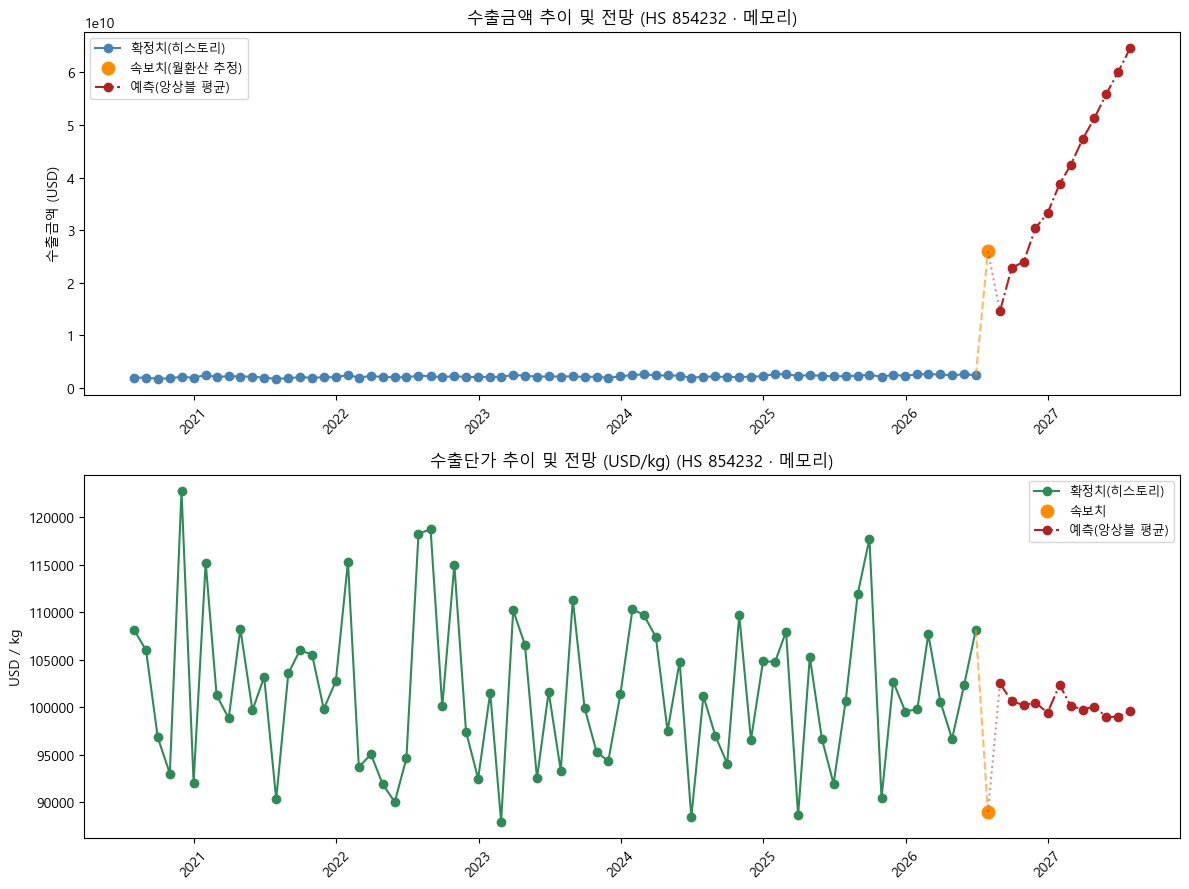

[완료] 차트: C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\reports\hs_854232_trend_forecast.png
[완료] 리포트: C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\reports\hs_854232_report.md


# 수출 속보치 결합 분석 리포트 — HS 854232 (메모리)

- 생성 시각: 2026-07-22 21:48
- 속보치 기준일: 2026-07-20

## 1. 현재 추세 요약

- 당월(속보치 월환산) 수출금액: **26,011,431,490 USD** (전월비 +960.00%)
- 당월(속보치) 수출단가: **89,003.97 USD/kg** (전월비 -17.71%)
- 전년동월비 수출금액: **+1048.82%**, 수출단가: **-11.59%**

## 2. 추이 및 전망 그래프


## 3. 향후 12개월 예측 (SARIMA / Theta / ExponentialSmoothing 앙상블 평균)

- 사용된 모델(수출금액): SARIMA, Theta, ETS
- 사용된 모델(수출단가): SARIMA, Theta, ETS

| 예측월 | 수출금액(USD) | 수출단가(USD/kg) |
|---|---:|---:|
| 2026-08 | 14,625,894,279 | 102,518.10 |
| 2026-09 | 22,839,511,544 | 100,621.09 |
| 2026-10 | 24,038,697,339 | 100,243.91 |
| 2026-11 | 30,416,826,867 | 100,487.89 |
| 2026-12 | 33,259,265,009 | 99,436.15 |
| 2027-01 | 38,803,628,694 | 102,366.21 |
| 2027-02 | 42,326,395,920 | 100,175.85 |
| 2027-03 | 47,325,736,259 | 99,761.99 |
| 2027-04 | 51,260,640,072 | 100,079.97 |
| 2027-05 | 55,922,909,367 | 98,970.77 |
| 2027-06 | 60,039,033,172 | 99,026.42 |
| 2027-07 | 64,611,933,350 | 99,605.47 |



[처리 시작] C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\2026_07_20\수출입통계 잠정치조회 (1).xlsx
[1/5] 파싱 완료 | HS코드=852351 | 기간=2026년07월01~20일 | report_date=2026-07-20 | 국가수=50
[2/5] DB 저장 완료 (korea_export_quick_report_data, append-only) | 이번 수집 50건 추가 (기존 이력은 덮어쓰지 않고 그대로 보존됨)
[3/5] 히스토리 결합 완료 | 총 73개월 (적용 배율[business_day]=1.643 | 참고: 달력일기준=1.550, 영업일기준=1.643)
[메모리] forecast_one_from_pivot_inline 실행 전: 452.56 MB

[예측 중] SARIMA 모델...
[메모리] forecast_sarima 실행 전: 452.56 MB
[메모리] find_best_sarima_params 실행 전: 452.56 MB
[메모리] find_best_sarima_params 실행 후: 448.61 MB (변화: -3.95 MB)
[메모리] forecast_sarima 실행 후: 448.61 MB (변화: -3.95 MB)

[예측 중] Theta 모델...
[메모리] forecast_theta 실행 전: 448.61 MB
[메모리] forecast_theta 실행 후: 448.62 MB (변화: +0.00 MB)

[예측 중] ETS 모델...
[메모리] forecast_ets 실행 전: 448.62 MB
[메모리] forecast_ets 실행 후: 448.70 MB (변화: +0.08 MB)
[메모리] forecast_one_from_pivot_inline 실행 후: 448.70 MB (변화: -3.86 MB)
[메모리] forecast_one_from_pivot_inline 실행 전: 448.70 MB

[예측 중] SARIMA 모델...
[메

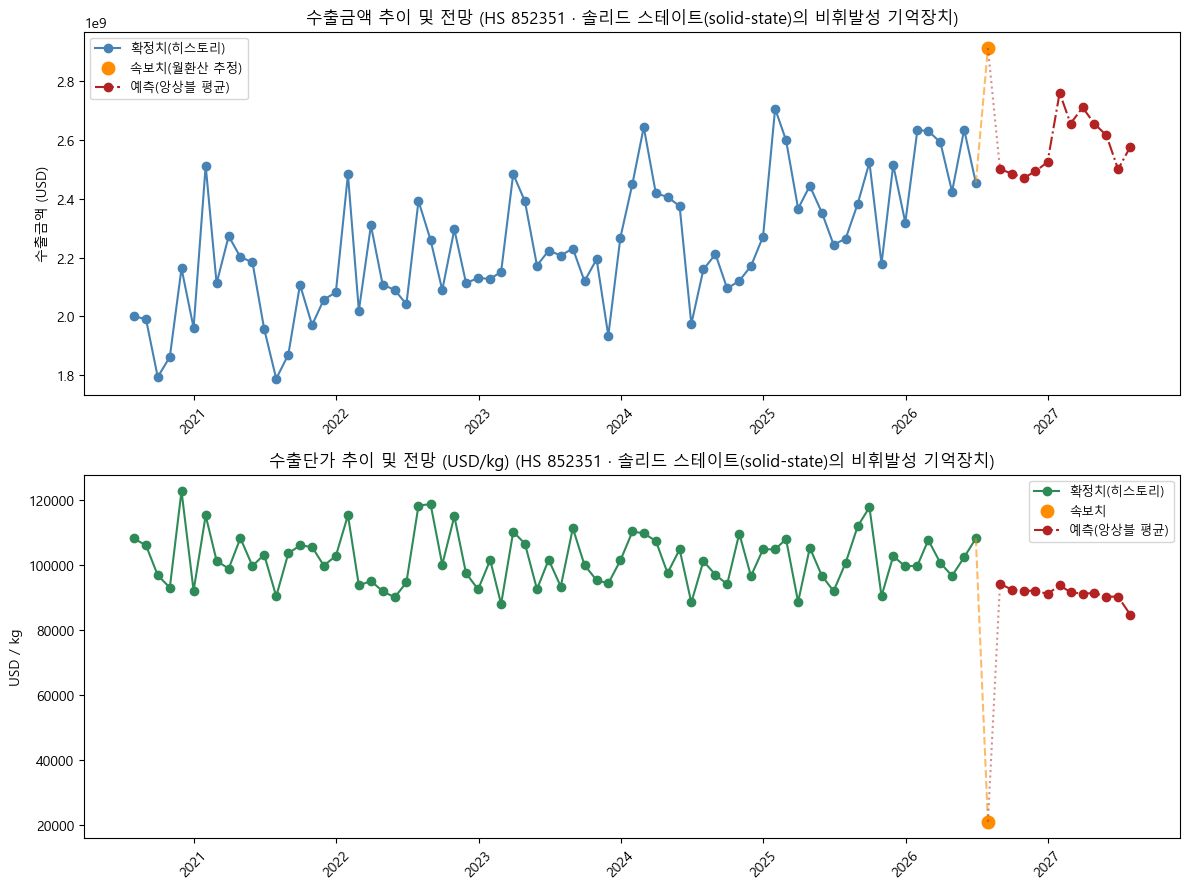

[완료] 차트: C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\reports\hs_852351_trend_forecast.png
[완료] 리포트: C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\reports\hs_852351_report.md


# 수출 속보치 결합 분석 리포트 — HS 852351 (솔리드 스테이트(solid-state)의 비휘발성 기억장치)

- 생성 시각: 2026-07-22 21:48
- 속보치 기준일: 2026-07-20

## 1. 현재 추세 요약

- 당월(속보치 월환산) 수출금액: **2,912,278,924 USD** (전월비 +18.68%)
- 당월(속보치) 수출단가: **21,069.49 USD/kg** (전월비 -80.52%)
- 전년동월비 수출금액: **+28.62%**, 수출단가: **-79.07%**

## 2. 추이 및 전망 그래프


## 3. 향후 12개월 예측 (SARIMA / Theta / ExponentialSmoothing 앙상블 평균)

- 사용된 모델(수출금액): SARIMA, Theta, ETS
- 사용된 모델(수출단가): SARIMA, Theta, ETS

| 예측월 | 수출금액(USD) | 수출단가(USD/kg) |
|---|---:|---:|
| 2026-08 | 2,500,376,816 | 94,250.11 |
| 2026-09 | 2,485,747,358 | 92,406.44 |
| 2026-10 | 2,470,935,626 | 91,984.01 |
| 2026-11 | 2,493,166,621 | 92,135.95 |
| 2026-12 | 2,524,743,967 | 91,082.44 |
| 2027-01 | 2,760,014,191 | 93,745.39 |
| 2027-02 | 2,655,532,483 | 91,624.33 |
| 2027-03 | 2,710,223,887 | 91,165.77 |
| 2027-04 | 2,655,096,832 | 91,387.57 |
| 2027-05 | 2,615,386,441 | 90,277.22 |
| 2027-06 | 2,500,047,351 | 90,255.43 |
| 2027-07 | 2,575,875,591 | 84,765.18 |



[처리 시작] C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\2026_07_20\수출입통계 잠정치조회 (2).xlsx
[1/5] 파싱 완료 | HS코드=847330 | 기간=2026년07월01~20일 | report_date=2026-07-20 | 국가수=50
[2/5] DB 저장 완료 (korea_export_quick_report_data, append-only) | 이번 수집 50건 추가 (기존 이력은 덮어쓰지 않고 그대로 보존됨)
[3/5] 히스토리 결합 완료 | 총 73개월 (적용 배율[business_day]=1.643 | 참고: 달력일기준=1.550, 영업일기준=1.643)
[메모리] forecast_one_from_pivot_inline 실행 전: 455.65 MB

[예측 중] SARIMA 모델...
[메모리] forecast_sarima 실행 전: 455.65 MB
[메모리] find_best_sarima_params 실행 전: 455.65 MB
[메모리] find_best_sarima_params 실행 후: 450.34 MB (변화: -5.30 MB)
[메모리] forecast_sarima 실행 후: 450.34 MB (변화: -5.30 MB)

[예측 중] Theta 모델...
[메모리] forecast_theta 실행 전: 450.34 MB
[메모리] forecast_theta 실행 후: 450.34 MB (변화: +0.00 MB)

[예측 중] ETS 모델...
[메모리] forecast_ets 실행 전: 450.34 MB
[메모리] forecast_ets 실행 후: 450.43 MB (변화: +0.09 MB)
[메모리] forecast_one_from_pivot_inline 실행 후: 450.43 MB (변화: -5.21 MB)
[메모리] forecast_one_from_pivot_inline 실행 전: 450.43 MB

[예측 중] SARIMA 모델...
[메

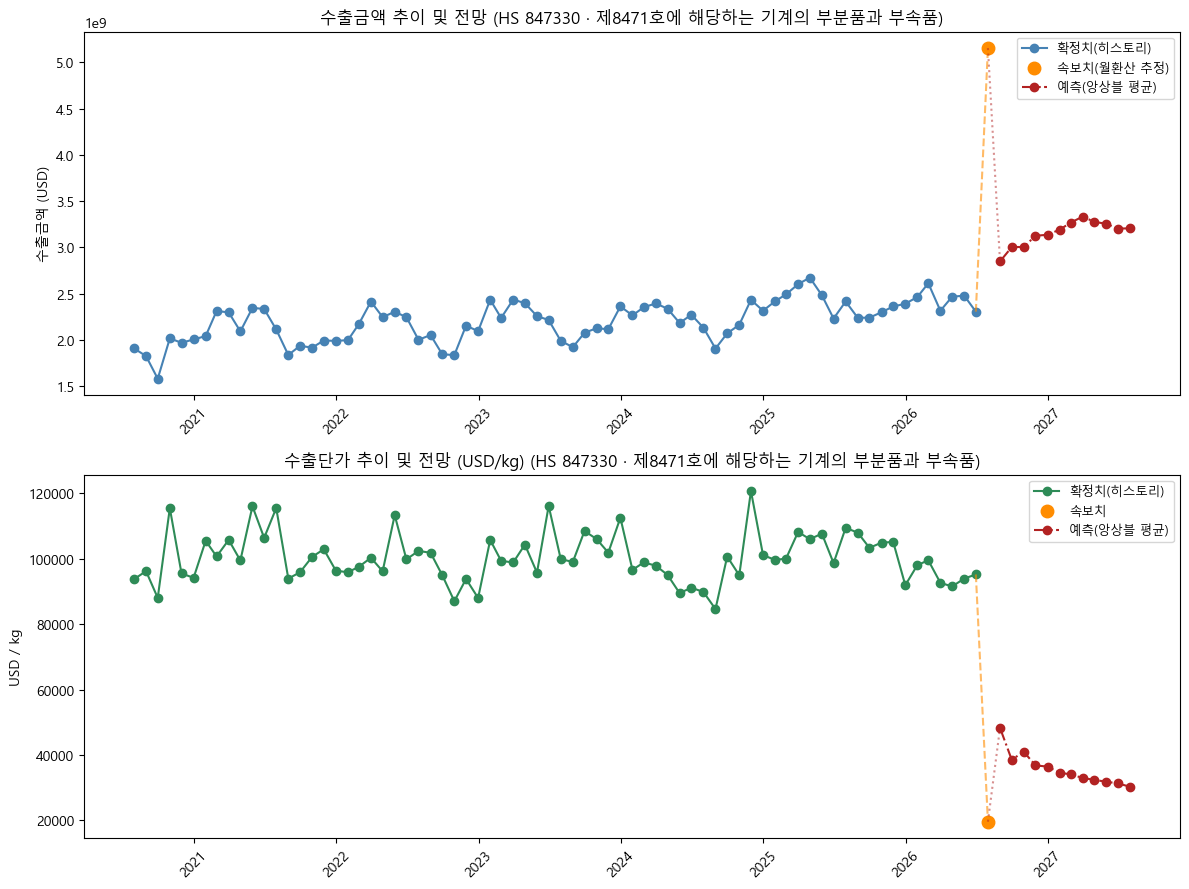

[완료] 차트: C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\reports\hs_847330_trend_forecast.png
[완료] 리포트: C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\reports\hs_847330_report.md


# 수출 속보치 결합 분석 리포트 — HS 847330 (제8471호에 해당하는 기계의 부분품과 부속품)

- 생성 시각: 2026-07-22 21:49
- 속보치 기준일: 2026-07-20

## 1. 현재 추세 요약

- 당월(속보치 월환산) 수출금액: **5,153,792,364 USD** (전월비 +123.66%)
- 당월(속보치) 수출단가: **19,625.20 USD/kg** (전월비 -79.39%)
- 전년동월비 수출금액: **+113.48%**, 수출단가: **-82.07%**

## 2. 추이 및 전망 그래프


## 3. 향후 12개월 예측 (SARIMA / Theta / ExponentialSmoothing 앙상블 평균)

- 사용된 모델(수출금액): SARIMA, Theta, ETS
- 사용된 모델(수출단가): SARIMA, Theta, ETS

| 예측월 | 수출금액(USD) | 수출단가(USD/kg) |
|---|---:|---:|
| 2026-08 | 2,847,172,300 | 48,307.38 |
| 2026-09 | 3,001,907,024 | 38,587.29 |
| 2026-10 | 3,004,049,428 | 40,994.06 |
| 2026-11 | 3,124,421,748 | 36,832.31 |
| 2026-12 | 3,135,448,345 | 36,476.09 |
| 2027-01 | 3,190,365,562 | 34,580.06 |
| 2027-02 | 3,265,836,201 | 34,120.98 |
| 2027-03 | 3,331,443,833 | 32,993.09 |
| 2027-04 | 3,275,143,849 | 32,421.60 |
| 2027-05 | 3,253,402,193 | 31,826.68 |
| 2027-06 | 3,202,009,563 | 31,346.37 |
| 2027-07 | 3,205,078,176 | 30,282.93 |



전체 완료: 3개 HS코드 처리


In [13]:
INPUT_FILES = [
    r"C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\2026_07_20\수출입통계 잠정치조회.xlsx",
    r"C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\2026_07_20\수출입통계 잠정치조회 (1).xlsx",
    r"C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\2026_07_20\수출입통계 잠정치조회 (2).xlsx",
]

engine_sqlite = get_engine("sqlite", sqlite_path="export_pipeline.db")

results_sqlite = []
for path in INPUT_FILES:
    results_sqlite.append(
        process_one_file(path, engine_sqlite, backend="sqlite", seed_history_if_missing=True)
    )

print(f"\n전체 완료: {len(results_sqlite)}개 HS코드 처리")

## 10. 실행 — 운영 (MySQL)

실제 사내 MySQL 서버(`korea_monthly_trade_data`가 있는 DB)에 접속 가능한 환경(사용자 PC/서버)에서만
실행하세요. 이 코드는 claude.ai 샌드박스에서는 네트워크 제약으로 접속 자체를 검증하지 못했습니다.

먼저 아래 환경변수를 설정한 뒤 실행하세요 (터미널에서 `export`하거나, 노트북 상단에서 `os.environ[...] = ...`):

```
KOREA_TRADE_DB_HOST
KOREA_TRADE_DB_PORT      (기본 3307)
KOREA_TRADE_DB_USER
KOREA_TRADE_DB_PASSWORD
KOREA_TRADE_DB_NAME      (기본 investar)
```

`seed_history_if_missing`는 **False**로 둡니다 — 운영 모드에서 실제 히스토리가 없으면
예측을 생략하고 경고만 표시하는 것이 올바른 동작입니다.



[처리 시작] C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\2026_07_20\수출입통계 잠정치조회.xlsx
[1/5] 파싱 완료 | HS코드=854232 | 기간=2026년07월01~20일 | report_date=2026-07-20 | 국가수=50
[마이그레이션] 구버전 korea_export_quick_report_data 테이블을 발견했습니다 (collected_at 컬럼 없음). 새 append-only 스키마로 이관합니다.
[마이그레이션 완료] 기존 데이터 150건을 새 스키마로 이관했습니다. 원본은 'korea_export_quick_report_data_old_backup' 테이블에 그대로 백업되어 있습니다(삭제 안 함).
[2/5] DB 저장 완료 (korea_export_quick_report_data, append-only) | 이번 수집 50건 추가 (기존 이력은 덮어쓰지 않고 그대로 보존됨)
[3/5] 히스토리 결합 완료 | 총 235개월 (적용 배율[business_day]=1.643 | 참고: 달력일기준=1.550, 영업일기준=1.643)
[메모리] forecast_one_from_pivot_inline 실행 전: 468.02 MB

[예측 중] SARIMA 모델...
[메모리] forecast_sarima 실행 전: 468.02 MB
[메모리] find_best_sarima_params 실행 전: 468.02 MB
[메모리] find_best_sarima_params 실행 후: 466.48 MB (변화: -1.54 MB)
[메모리] forecast_sarima 실행 후: 466.49 MB (변화: -1.52 MB)

[예측 중] Theta 모델...
[메모리] forecast_theta 실행 전: 466.49 MB
[메모리] forecast_theta 실행 후: 466.49 MB (변화: +0.00 MB)

[예측 중] ETS 모델...
[메모리] foreca

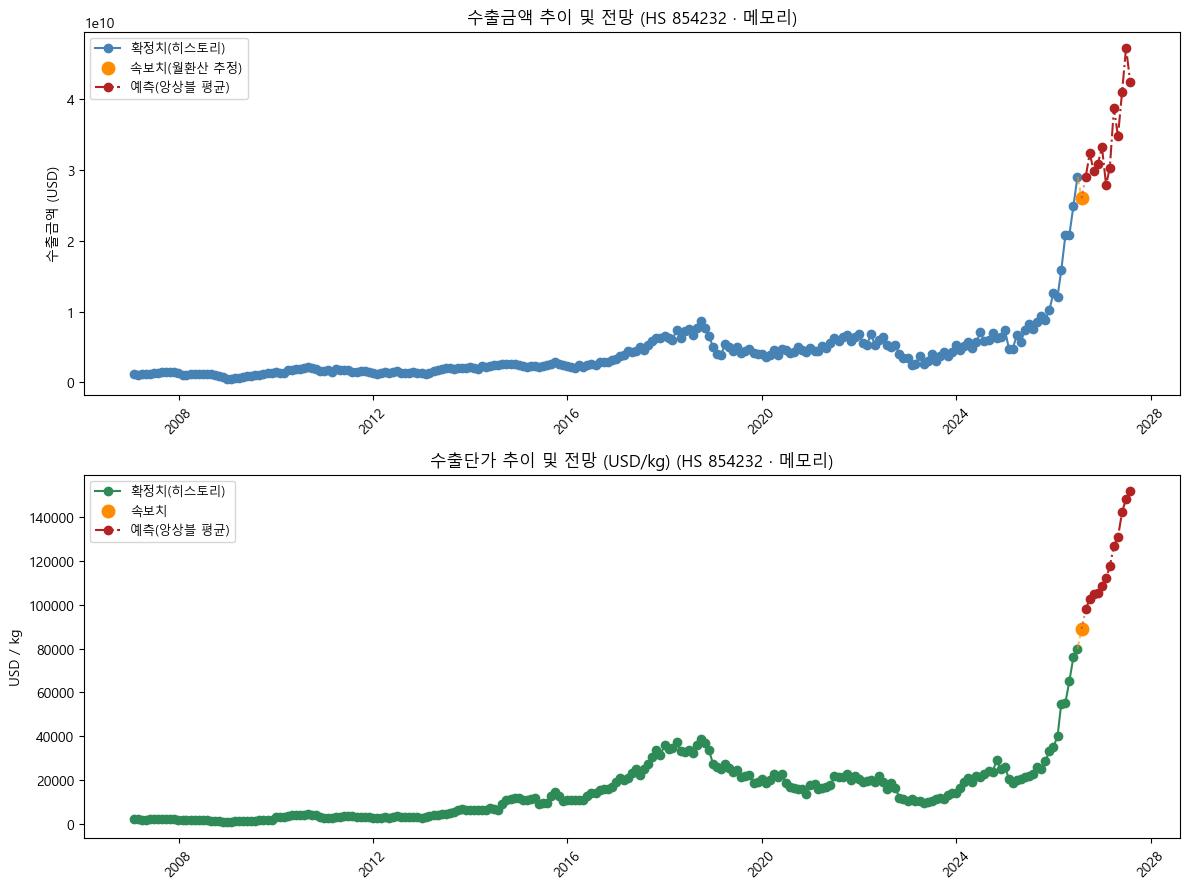

[완료] 차트: C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\reports\hs_854232_trend_forecast.png
[완료] 리포트: C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\reports\hs_854232_report.md


# 수출 속보치 결합 분석 리포트 — HS 854232 (메모리)

- 생성 시각: 2026-07-22 21:50
- 속보치 기준일: 2026-07-20

## 1. 현재 추세 요약

- 당월(속보치 월환산) 수출금액: **26,011,431,490 USD** (전월비 -10.43%)
- 당월(속보치) 수출단가: **89,003.97 USD/kg** (전월비 +11.53%)
- 전년동월비 수출금액: **+243.69%**, 수출단가: **+289.91%**

## 2. 추이 및 전망 그래프


## 3. 향후 12개월 예측 (SARIMA / Theta / ExponentialSmoothing 앙상블 평균)

- 사용된 모델(수출금액): SARIMA, Theta, ETS
- 사용된 모델(수출단가): SARIMA, Theta, ETS

| 예측월 | 수출금액(USD) | 수출단가(USD/kg) |
|---|---:|---:|
| 2026-08 | 29,068,986,339 | 97,829.92 |
| 2026-09 | 32,326,349,234 | 102,745.37 |
| 2026-10 | 29,804,228,267 | 104,995.72 |
| 2026-11 | 30,870,113,970 | 105,456.54 |
| 2026-12 | 33,196,038,290 | 108,682.72 |
| 2027-01 | 27,863,038,872 | 112,032.11 |
| 2027-02 | 30,340,153,202 | 117,529.89 |
| 2027-03 | 38,766,339,030 | 126,887.35 |
| 2027-04 | 34,720,352,913 | 130,794.01 |
| 2027-05 | 40,995,051,501 | 142,060.82 |
| 2027-06 | 47,200,654,390 | 148,305.47 |
| 2027-07 | 42,438,099,635 | 151,746.34 |



[처리 시작] C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\2026_07_20\수출입통계 잠정치조회 (1).xlsx
[1/5] 파싱 완료 | HS코드=852351 | 기간=2026년07월01~20일 | report_date=2026-07-20 | 국가수=50
[2/5] DB 저장 완료 (korea_export_quick_report_data, append-only) | 이번 수집 50건 추가 (기존 이력은 덮어쓰지 않고 그대로 보존됨)
[3/5] 히스토리 결합 완료 | 총 235개월 (적용 배율[business_day]=1.643 | 참고: 달력일기준=1.550, 영업일기준=1.643)
[메모리] forecast_one_from_pivot_inline 실행 전: 461.14 MB

[예측 중] SARIMA 모델...
[메모리] forecast_sarima 실행 전: 461.14 MB
[메모리] find_best_sarima_params 실행 전: 461.14 MB
[메모리] find_best_sarima_params 실행 후: 467.40 MB (변화: +6.26 MB)
[메모리] forecast_sarima 실행 후: 467.41 MB (변화: +6.27 MB)

[예측 중] Theta 모델...
[메모리] forecast_theta 실행 전: 467.41 MB
[메모리] forecast_theta 실행 후: 467.41 MB (변화: +0.00 MB)

[예측 중] ETS 모델...
[메모리] forecast_ets 실행 전: 467.41 MB
[메모리] forecast_ets 실행 후: 467.45 MB (변화: +0.04 MB)
[메모리] forecast_one_from_pivot_inline 실행 후: 467.45 MB (변화: +6.30 MB)
[메모리] forecast_one_from_pivot_inline 실행 전: 467.45 MB

[예측 중] SARIMA 모델...
[

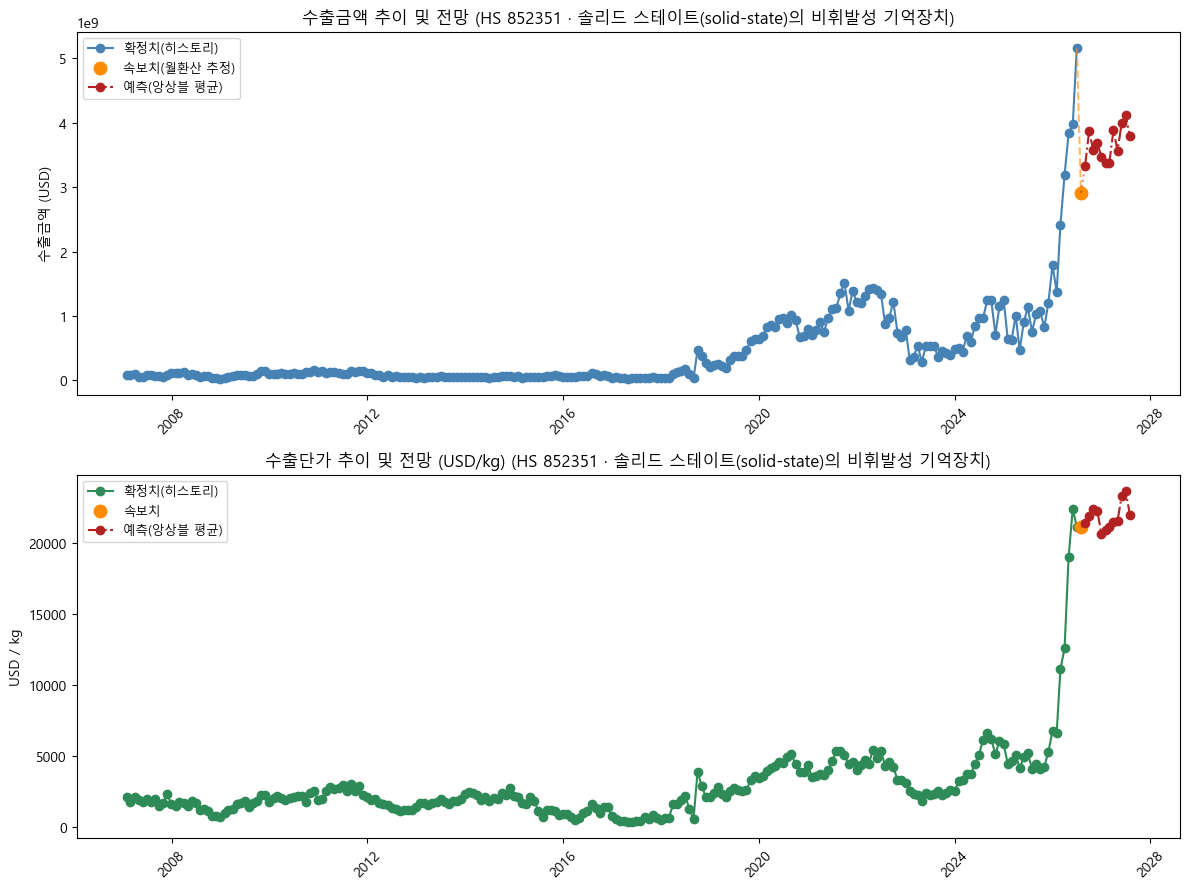

[완료] 차트: C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\reports\hs_852351_trend_forecast.png
[완료] 리포트: C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\reports\hs_852351_report.md


# 수출 속보치 결합 분석 리포트 — HS 852351 (솔리드 스테이트(solid-state)의 비휘발성 기억장치)

- 생성 시각: 2026-07-22 21:51
- 속보치 기준일: 2026-07-20

## 1. 현재 추세 요약

- 당월(속보치 월환산) 수출금액: **2,912,278,924 USD** (전월비 -43.56%)
- 당월(속보치) 수출단가: **21,069.49 USD/kg** (전월비 -0.21%)
- 전년동월비 수출금액: **+287.31%**, 수출단가: **+415.47%**

## 2. 추이 및 전망 그래프


## 3. 향후 12개월 예측 (SARIMA / Theta / ExponentialSmoothing 앙상블 평균)

- 사용된 모델(수출금액): SARIMA, Theta, ETS
- 사용된 모델(수출단가): SARIMA, Theta, ETS

| 예측월 | 수출금액(USD) | 수출단가(USD/kg) |
|---|---:|---:|
| 2026-08 | 3,325,760,241 | 21,349.29 |
| 2026-09 | 3,873,417,972 | 21,864.45 |
| 2026-10 | 3,572,345,128 | 22,344.08 |
| 2026-11 | 3,691,637,832 | 22,255.59 |
| 2026-12 | 3,466,621,352 | 20,611.27 |
| 2027-01 | 3,382,478,335 | 20,882.74 |
| 2027-02 | 3,377,008,628 | 21,102.75 |
| 2027-03 | 3,890,581,727 | 21,459.31 |
| 2027-04 | 3,562,085,123 | 21,541.48 |
| 2027-05 | 3,990,876,774 | 23,263.73 |
| 2027-06 | 4,127,351,983 | 23,631.75 |
| 2027-07 | 3,788,018,538 | 21,966.42 |



[처리 시작] C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\2026_07_20\수출입통계 잠정치조회 (2).xlsx
[1/5] 파싱 완료 | HS코드=847330 | 기간=2026년07월01~20일 | report_date=2026-07-20 | 국가수=50
[2/5] DB 저장 완료 (korea_export_quick_report_data, append-only) | 이번 수집 50건 추가 (기존 이력은 덮어쓰지 않고 그대로 보존됨)
[3/5] 히스토리 결합 완료 | 총 235개월 (적용 배율[business_day]=1.643 | 참고: 달력일기준=1.550, 영업일기준=1.643)
[메모리] forecast_one_from_pivot_inline 실행 전: 471.90 MB

[예측 중] SARIMA 모델...
[메모리] forecast_sarima 실행 전: 471.90 MB
[메모리] find_best_sarima_params 실행 전: 471.90 MB
[메모리] find_best_sarima_params 실행 후: 465.84 MB (변화: -6.07 MB)
[메모리] forecast_sarima 실행 후: 465.84 MB (변화: -6.07 MB)

[예측 중] Theta 모델...
[메모리] forecast_theta 실행 전: 465.84 MB
[메모리] forecast_theta 실행 후: 465.84 MB (변화: +0.00 MB)

[예측 중] ETS 모델...
[메모리] forecast_ets 실행 전: 465.84 MB
[메모리] forecast_ets 실행 후: 465.84 MB (변화: +0.00 MB)
[메모리] forecast_one_from_pivot_inline 실행 후: 465.84 MB (변화: -6.07 MB)
[메모리] forecast_one_from_pivot_inline 실행 전: 465.84 MB

[예측 중] SARIMA 모델...
[

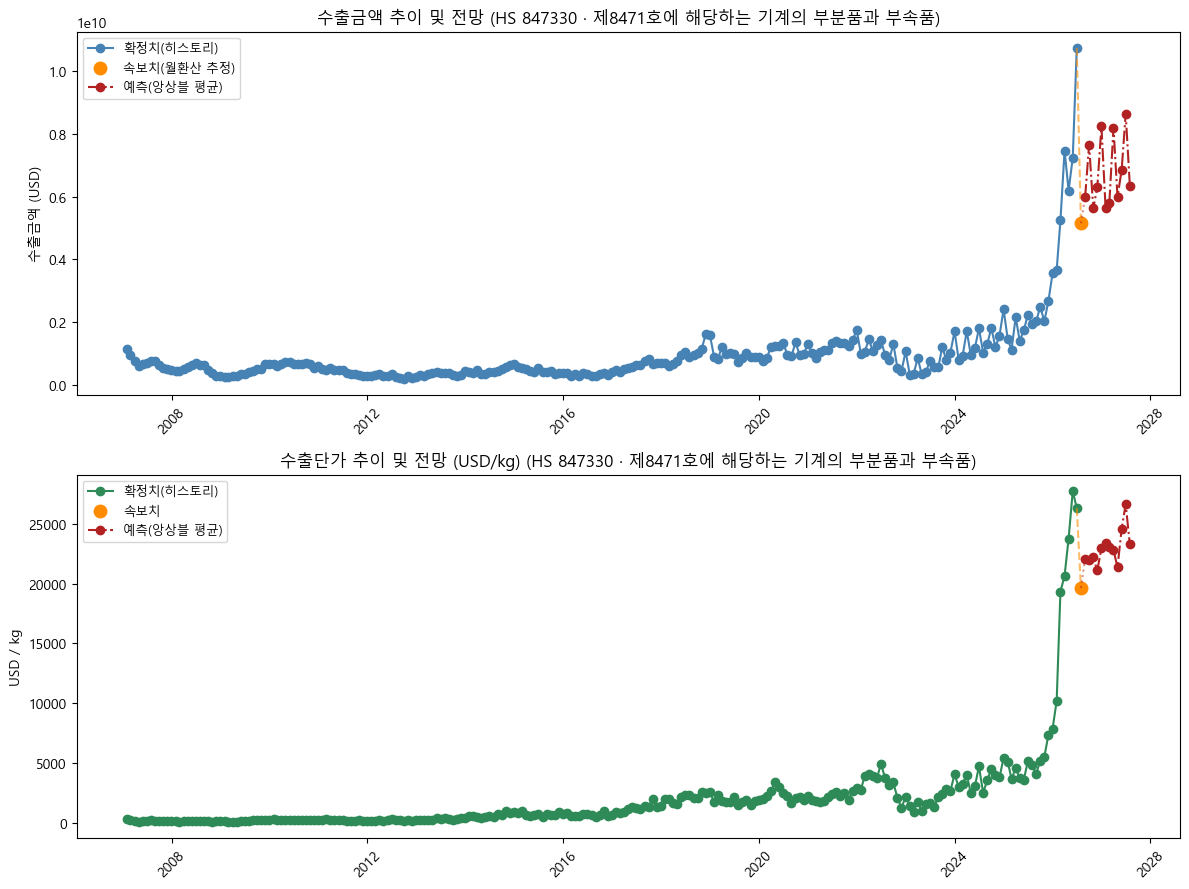

[완료] 차트: C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\reports\hs_847330_trend_forecast.png
[완료] 리포트: C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\reports\hs_847330_report.md


# 수출 속보치 결합 분석 리포트 — HS 847330 (제8471호에 해당하는 기계의 부분품과 부속품)

- 생성 시각: 2026-07-22 21:52
- 속보치 기준일: 2026-07-20

## 1. 현재 추세 요약

- 당월(속보치 월환산) 수출금액: **5,153,792,364 USD** (전월비 -51.96%)
- 당월(속보치) 수출단가: **19,625.20 USD/kg** (전월비 -25.34%)
- 전년동월비 수출금액: **+164.48%**, 수출단가: **+306.78%**

## 2. 추이 및 전망 그래프


## 3. 향후 12개월 예측 (SARIMA / Theta / ExponentialSmoothing 앙상블 평균)

- 사용된 모델(수출금액): SARIMA, Theta, ETS
- 사용된 모델(수출단가): SARIMA, Theta, ETS

| 예측월 | 수출금액(USD) | 수출단가(USD/kg) |
|---|---:|---:|
| 2026-08 | 5,974,377,576 | 22,062.13 |
| 2026-09 | 7,652,720,462 | 21,958.68 |
| 2026-10 | 5,625,786,176 | 22,183.66 |
| 2026-11 | 6,292,535,620 | 21,093.27 |
| 2026-12 | 8,233,766,634 | 22,959.96 |
| 2027-01 | 5,638,012,135 | 23,347.22 |
| 2027-02 | 5,804,520,479 | 23,047.14 |
| 2027-03 | 8,198,081,997 | 22,794.15 |
| 2027-04 | 5,984,554,355 | 21,354.63 |
| 2027-05 | 6,858,977,873 | 24,589.72 |
| 2027-06 | 8,637,399,538 | 26,619.94 |
| 2027-07 | 6,350,193,154 | 23,261.37 |



전체 완료: 3개 HS코드 처리


In [14]:
os.environ["KOREA_TRADE_DB_USER"] = "stox7412"
os.environ["KOREA_TRADE_DB_PASSWORD"] = "Apt106503!~"

INPUT_FILES_PROD = [
    r"C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\2026_07_20\수출입통계 잠정치조회.xlsx",
    r"C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\2026_07_20\수출입통계 잠정치조회 (1).xlsx",
    r"C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\2026_07_20\수출입통계 잠정치조회 (2).xlsx",
]

engine_mysql = get_engine("mysql")

results_mysql = []
for path in INPUT_FILES_PROD:
    results_mysql.append(
        process_one_file(path, engine_mysql, backend="mysql", seed_history_if_missing=False)
    )

print(f"\n전체 완료: {len(results_mysql)}개 HS코드 처리")

In [15]:
def show_combined(results, hs_code=None):
    """
    results: process_one_file()의 반환값 리스트 (results_sqlite 또는 results_mysql)
    hs_code: 특정 HS코드만 보고 싶으면 지정 (예: "854232"), None이면 전체 출력
    """
    for r in results:
        if hs_code and r["hs_code"] != hs_code:
            continue

        df = r["combined"].copy()
        df["기간"] = df["date"].dt.strftime("%Y-%m")
        df = df[["기간", "수출금액", "수출중량", "수출단가",
                 "status", "raw_partial_amount_usd", "scale_factor", "method_used"]]
        df = df.rename(columns={
            "status": "상태",
            "raw_partial_amount_usd": "원본(부분기간)금액",
            "scale_factor": "적용배율",
            "method_used": "보정방법",
        })

        print(f"\n{'='*70}\nHS {r['hs_code']} 결합 데이터 (총 {len(df)}개월)\n{'='*70}")
        print("상태: confirmed=확정월 실적 / flash_estimate=당월 속보치 기반 추정치")

        styled = (
            df.style
            .format({
                "수출금액": "{:,.0f}",
                "수출중량": "{:,.1f}",
                "수출단가": "{:,.2f}",
                "원본(부분기간)금액": lambda v: "" if pd.isna(v) else f"{v:,.0f}",
                "적용배율": "{:,.3f}",
            })
            .apply(
                lambda row: ["background-color: #fff3cd" if row["상태"] == "flash_estimate" else "" for _ in row],
                axis=1,
            )
        )
        display(styled)


# 사용 예시:
show_combined(results_mysql)                 # 전체 HS코드 결합 데이터 표시
# show_combined(results_mysql, "854232")     # 특정 HS코드만 보고 싶을 때



HS 854232 결합 데이터 (총 235개월)
상태: confirmed=확정월 실적 / flash_estimate=당월 속보치 기반 추정치


indicator,기간,수출금액,수출중량,수출단가,상태,원본(부분기간)금액,적용배율,보정방법
0,2007-01,"1,246,690,000","504,237.0","2,472.43",confirmed,,1.000,actual
1,2007-02,"1,101,980,000","463,604.0","2,376.99",confirmed,,1.000,actual
2,2007-03,"1,183,710,000","604,003.0","1,959.78",confirmed,,1.000,actual
3,2007-04,"1,162,200,000","610,139.0","1,904.81",confirmed,,1.000,actual
4,2007-05,"1,144,160,000","524,150.0","2,182.89",confirmed,,1.000,actual
5,2007-06,"1,346,530,000","587,148.0","2,293.34",confirmed,,1.000,actual
6,2007-07,"1,399,820,000","599,106.0","2,336.51",confirmed,,1.000,actual
7,2007-08,"1,534,470,000","631,444.0","2,430.10",confirmed,,1.000,actual
8,2007-09,"1,459,700,000","580,110.0","2,516.25",confirmed,,1.000,actual
9,2007-10,"1,520,700,000","631,415.0","2,408.40",confirmed,,1.000,actual



HS 852351 결합 데이터 (총 235개월)
상태: confirmed=확정월 실적 / flash_estimate=당월 속보치 기반 추정치


indicator,기간,수출금액,수출중량,수출단가,상태,원본(부분기간)금액,적용배율,보정방법
0,2007-01,"79,537,100","38,165.0","2,084.03",confirmed,,1.000,actual
1,2007-02,"77,545,200","43,948.0","1,764.48",confirmed,,1.000,actual
2,2007-03,"93,742,200","45,086.0","2,079.19",confirmed,,1.000,actual
3,2007-04,"57,912,000","31,214.0","1,855.32",confirmed,,1.000,actual
4,2007-05,"52,332,400","30,578.0","1,711.44",confirmed,,1.000,actual
5,2007-06,"79,217,200","40,653.0","1,948.62",confirmed,,1.000,actual
6,2007-07,"82,135,700","47,757.0","1,719.87",confirmed,,1.000,actual
7,2007-08,"71,402,700","36,583.0","1,951.80",confirmed,,1.000,actual
8,2007-09,"59,744,500","41,967.0","1,423.61",confirmed,,1.000,actual
9,2007-10,"45,887,800","27,746.0","1,653.85",confirmed,,1.000,actual



HS 847330 결합 데이터 (총 235개월)
상태: confirmed=확정월 실적 / flash_estimate=당월 속보치 기반 추정치


indicator,기간,수출금액,수출중량,수출단가,상태,원본(부분기간)금액,적용배율,보정방법
0,2007-01,"1,151,880,000","3,692,820.0",311.92,confirmed,,1.000,actual
1,2007-02,"956,981,000","3,772,240.0",253.69,confirmed,,1.000,actual
2,2007-03,"784,185,000","4,716,050.0",166.28,confirmed,,1.000,actual
3,2007-04,"614,712,000","4,765,420.0",128.99,confirmed,,1.000,actual
4,2007-05,"661,237,000","4,263,990.0",155.07,confirmed,,1.000,actual
5,2007-06,"691,362,000","3,585,910.0",192.80,confirmed,,1.000,actual
6,2007-07,"770,644,000","3,333,350.0",231.19,confirmed,,1.000,actual
7,2007-08,"773,343,000","3,595,960.0",215.06,confirmed,,1.000,actual
8,2007-09,"635,065,000","3,341,790.0",190.04,confirmed,,1.000,actual
9,2007-10,"554,418,000","3,637,400.0",152.42,confirmed,,1.000,actual


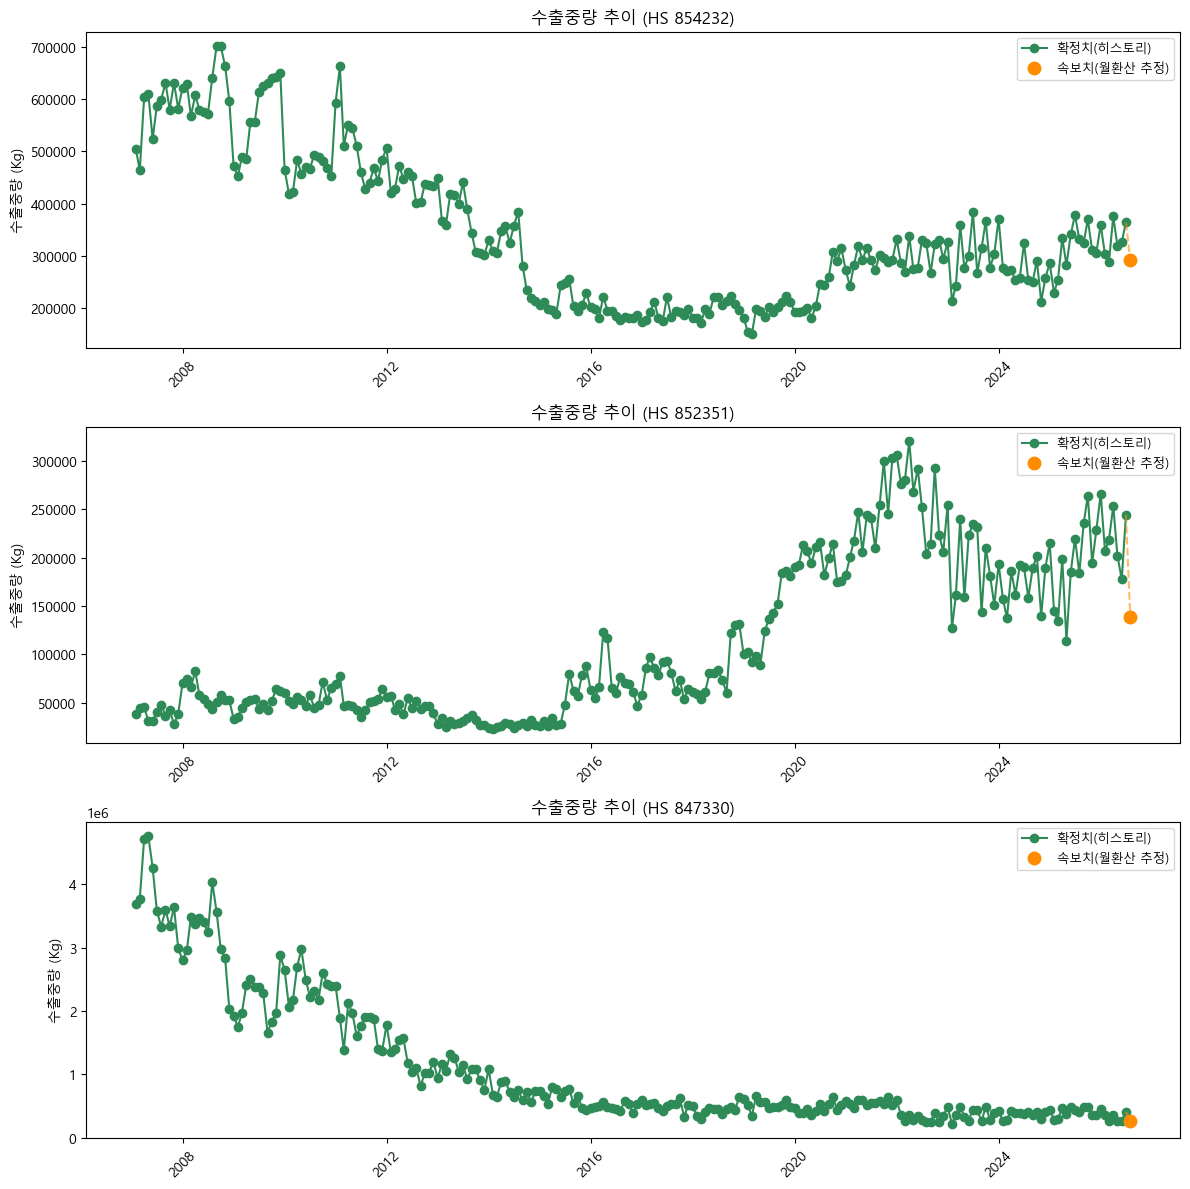

In [16]:
def plot_weight_by_hs(results, output_dir=None, filename="hs_weight_by_code.png"):
    """
    results: process_one_file()의 반환값 리스트 (results_sqlite 또는 results_mysql)
    HS코드마다 별도의 서브플롯으로 분리해서 보여줍니다.
    output_dir: 지정하면 PNG로도 저장 (예: CHART_OUTPUT_DIR). None이면 화면에만 표시.
    """
    n = len(results)
    fig, axes = plt.subplots(n, 1, figsize=(12, 4 * n), sharex=False)
    if n == 1:
        axes = [axes]

    for ax, r in zip(axes, results):
        combined = r["combined"]
        hs_code = r["hs_code"]
        hist = combined[~combined["is_flash"]]
        flash = combined[combined["is_flash"]]

        ax.plot(hist["date"], hist["수출중량"], marker="o", color="seagreen", label="확정치(히스토리)")

        if not flash.empty:
            ax.plot(flash["date"], flash["수출중량"], marker="o", markersize=9,
                     linestyle="None", color="darkorange", label="속보치(월환산 추정)")
            last_hist = hist.tail(1)
            if not last_hist.empty:
                ax.plot(
                    pd.concat([last_hist["date"], flash["date"]]),
                    pd.concat([last_hist["수출중량"], flash["수출중량"]]),
                    linestyle="--", color="darkorange", alpha=0.6,
                )

        ax.set_title(f"수출중량 추이 (HS {hs_code})")
        ax.set_ylabel("수출중량 (Kg)")
        ax.legend(fontsize=9)
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()

    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        out_path = os.path.join(output_dir, filename)
        plt.savefig(out_path, dpi=150)
        print(f"저장 완료: {out_path}")

    plt.show()
    plt.close(fig)


# 사용 예시:
plot_weight_by_hs(results_mysql)                      # 화면에만 표시
# plot_weight_by_hs(results_mysql, CHART_OUTPUT_DIR)   # 화면 표시 + PNG로도 저장

In [17]:
print("results_sqlite 존재:", "results_sqlite" in dir())
print("results_mysql 존재:", "results_mysql" in dir())

results_sqlite 존재: True
results_mysql 존재: True


## 11. 최종 결합 데이터 → 엑셀 추출 (Claude 등 외부 분석용)

예측 모델 결과와 상관없이, **`date | hs_code | item_name | 수출금액 | 수출중량 | 수출단가 | status`**
형태의 깔끔한 long format 테이블만 뽑아서 엑셀로 저장합니다.

- `status`: `confirmed`(확정월 실적) / `flash_estimate`(당월 속보치 기반 추정치)
- HS코드 여러 개를 하나의 long format 테이블로 합침 (세로로 쌓는 tidy 구조 — 분석 도구에 넣기 가장 쉬운 형태)
- 엑셀 파일에는 전체를 합친 `long_format` 시트 + HS코드별 개별 시트를 같이 저장 (수동으로 열어볼 때 편하도록)

`run_forecast=False`로 `process_one_file()`을 실행하면 예측/차트/리포트 없이 결합 테이블만 빠르게 얻을 수 있습니다:
```python
results_data_only = [
    process_one_file(p, engine, backend, seed_history_if_missing=True, run_forecast=False)
    for p in INPUT_FILES
]
```


In [18]:
import pandas as pd


def build_long_format_table(results) -> pd.DataFrame:
    """
    process_one_file()의 반환값 리스트(results)에서 결합 테이블만 뽑아
    date | hs_code | item_name | 수출금액 | 수출중량 | 수출단가 | status
    형태의 단일 long format 데이터프레임으로 합친다.

    - 여러 HS코드를 세로로 이어붙인 tidy(long) 구조라 pandas/엑셀/Claude 등
      어떤 도구로 열어도 바로 groupby, 필터, 피벗이 가능하다.
    - status: "confirmed"(확정월 실적) / "flash_estimate"(당월 속보치 기반 추정치)
    """
    frames = []
    for r in results:
        df = r["combined"].copy()
        df["hs_code"] = r["hs_code"]
        df["item_name"] = r.get("item_name", "")
        frames.append(df[["date", "hs_code", "item_name", "수출금액", "수출중량", "수출단가", "status"]])

    long_df = pd.concat(frames, ignore_index=True)
    long_df = long_df.sort_values(["hs_code", "date"]).reset_index(drop=True)
    return long_df


def export_dataset_to_excel(long_df: pd.DataFrame, output_path: str):
    """
    long_df를 엑셀로 저장.
      - "long_format" 시트: 전체 HS코드를 합친 tidy 테이블 (Claude 등 분석 도구에 넣기 좋은 기본 형태)
      - HS코드별 시트: 코드 하나씩 따로 봐야 할 때 편하도록 개별 시트도 같이 저장
    """
    with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
        long_df.to_excel(writer, sheet_name="long_format", index=False)

        for hs_code, sub in long_df.groupby("hs_code"):
            sheet_name = str(hs_code)[:31]  # 엑셀 시트명 31자 제한
            sub.to_excel(writer, sheet_name=sheet_name, index=False)

    print(f"엑셀 저장 완료: {output_path}")
    print(f"  - long_format 시트: {len(long_df)}행 (HS코드 {long_df['hs_code'].nunique()}개)")


print("build_long_format_table(), export_dataset_to_excel() 정의 완료")


build_long_format_table(), export_dataset_to_excel() 정의 완료


In [21]:
# ── 사용 예시 ──────────────────────────────────────────────
long_df = build_long_format_table(results_mysql)   # 또는 results_sqlite
long_df.head()
export_dataset_to_excel(long_df, os.path.join(FORECAST_OUTPUT_DIR, "수출_결합데이터_long.xlsx"))


엑셀 저장 완료: C:\Users\82108\OneDrive\INVESTMENT\한국_월간수출분석\export_quick_report\forecasts\수출_결합데이터_long.xlsx
  - long_format 시트: 705행 (HS코드 3개)
